# Descripción del problema


# Caracterización

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold,cross_val_score, validation_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from scipy.stats import norm
from scipy import stats
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

ImportError: cannot import name 'fetch_file' from 'sklearn.datasets._base' (c:\Users\Andrea Sanchez\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\datasets\_base.py)

In [11]:
# Carga del dataset
url = 'https://raw.githubusercontent.com/BrahianCarrera/Speaker-Recognition/main/dataset/accent-mfcc-data-1.csv'
df = pd.read_csv(url)

In [12]:
# Mostrar las primeras filas
df.head()

,language,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
0,ES,7.071476,-6.512900,7.650800,11.150783,-7.657312,12.484021,-11.709772,3.426596,1.462715,-2.812753,0.866538,-5.244274
1,ES,10.982967,-5.157445,3.952060,11.529381,-7.638047,12.136098,-12.036247,3.491943,0.595441,-4.508811,2.332147,-6.221857
2,ES,7.827108,-5.477472,7.816257,9.187592,-7.172511,11.715299,-13.847214,4.574075,-1.687559,-7.204041,-0.011847,-6.463144
3,ES,6.744083,-5.688920,6.546789,9.000183,-6.924963,11.710766,-12.374388,6.169879,-0.544747,-6.019237,1.358559,-6.356441
4,ES,5.836843,-5.326557,7.472265,8.847440,-6.773244,12.677218,-12.315061,4.416344,0.193500,-3.644812,2.151239,-6.816310


In [13]:
df.language.unique()

array(['ES', 'FR', 'GE', 'IT', 'UK', 'US'], dtype=object)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329 entries, 0 to 328
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   language  329 non-null    object 
 1   X1        329 non-null    float64
 2   X2        329 non-null    float64
 3   X3        329 non-null    float64
 4   X4        329 non-null    float64
 5   X5        329 non-null    float64
 6   X6        329 non-null    float64
 7   X7        329 non-null    float64
 8   X8        329 non-null    float64
 9   X9        329 non-null    float64
 10  X10       329 non-null    float64
 11  X11       329 non-null    float64
 12  X12       329 non-null    float64
dtypes: float64(12), object(1)
memory usage: 33.5+ KB


In [15]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
count,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000
mean,5.645227,-4.270814,2.635319,7.200207,-5.648733,9.810236,-9.408053,5.117328,-1.229432,-2.362288,2.430833,-3.980415
std,5.105302,3.514350,3.635323,4.310095,4.596180,3.624654,2.484117,2.650608,3.634849,5.042034,3.478467,2.985879
min,-6.067831,-14.972962,-6.186583,-8.844231,-15.656596,-3.528964,-15.365665,-2.873862,-15.510974,-11.429178,-13.664104,-13.724103
25%,2.065603,-6.515764,0.137042,4.700874,-8.417684,8.643563,-11.120860,3.482167,-1.749082,-5.083522,1.197789,-5.941409
50%,4.954206,-4.252512,2.029268,7.804680,-6.786670,10.379330,-9.710399,4.843103,-0.389970,-3.323147,3.169703,-4.374334
75%,9.793648,-1.560250,4.178026,10.129165,-4.463308,11.784360,-7.989370,6.588931,0.779993,-1.506037,4.673452,-2.191658
max,17.749851,3.570765,17.066487,16.178942,7.912809,21.445837,-0.424033,13.846083,4.789989,16.326455,9.166066,5.259430


In [16]:
description_by_accent = df.groupby("language").describe().transpose()
description_by_accent

language          ES         FR         GE         IT         UK          US
X1  count  29.000000  30.000000  30.000000  30.000000  45.000000  165.000000
    mean    9.870596   6.702179   3.838028   1.197758   2.569596    6.686435
    std     2.635284   5.407628   3.006764   3.430359   2.693104    5.374274
    min     5.836843  -2.339695  -2.880823  -4.835242  -6.067831   -4.222359
    25%     7.598763   2.307446   2.361031  -1.231737   1.467842    3.118493
...              ...        ...        ...        ...        ...         ...
X12 min    -6.816310  -9.614959  -9.162163  -8.731785  -8.869338  -13.724103
    25%    -5.847239  -6.672609  -6.105584  -4.969127  -6.091090   -5.739362
    50%    -4.294401  -5.363448  -5.231369  -3.735597  -5.029416   -3.306123
    75%    -2.191658  -3.908692  -3.360758  -2.238007  -3.873465   -1.227931
    max     1.079622  -1.761528  -1.504672   0.463408   0.910715    5.259430

[96 rows x 6 columns]

In [ ]:
# Contar cuántos registros hay por cada idiomaa
language_counts = df['language'].value_counts()
total = language_counts.sum()

# Imprimir valores por consola
print("Distribución de registros por idioma:")
for lang, count in language_counts.items():
    porcentaje = (count / total) * 100
    print(f"{lang}: {count} registros ({porcentaje:.2f}%)")

# Función para mostrar número y porcentaje en cada segmento de la gráfica
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'
    return my_autopct

# Crear gráfico de pastel
plt.figure(figsize=(4, 4))
plt.pie(
    language_counts,
    labels=language_counts.index,
    autopct=make_autopct(language_counts),
    startangle=90
)
plt.title('Distribución de registros por idioma')
plt.axis('equal')
plt.show()


Distribución de registros por idioma:
US: 165 registros (50.15%)
UK: 45 registros (13.68%)
FR: 30 registros (9.12%)
GE: 30 registros (9.12%)
IT: 30 registros (9.12%)
ES: 29 registros (8.81%)


ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.11 from "c:\Users\Andrea Sanchez\AppData\Local\Programs\Python\Python311\python.exe"
  * The NumPy version is: "1.23.5"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: No se puede encontrar el módulo especificado.


ImportError: numpy._core.multiarray failed to import

In [ ]:
# Indice de desbalance

class_counts = df['language'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Índice de desbalance: {imbalance_ratio}")

if imbalance_ratio > 3:
    print("Dataset desbalanceado")
else:
    print("Dataset balanceado")


Índice de desbalance: 5.689655172413793
Dataset desbalanceado


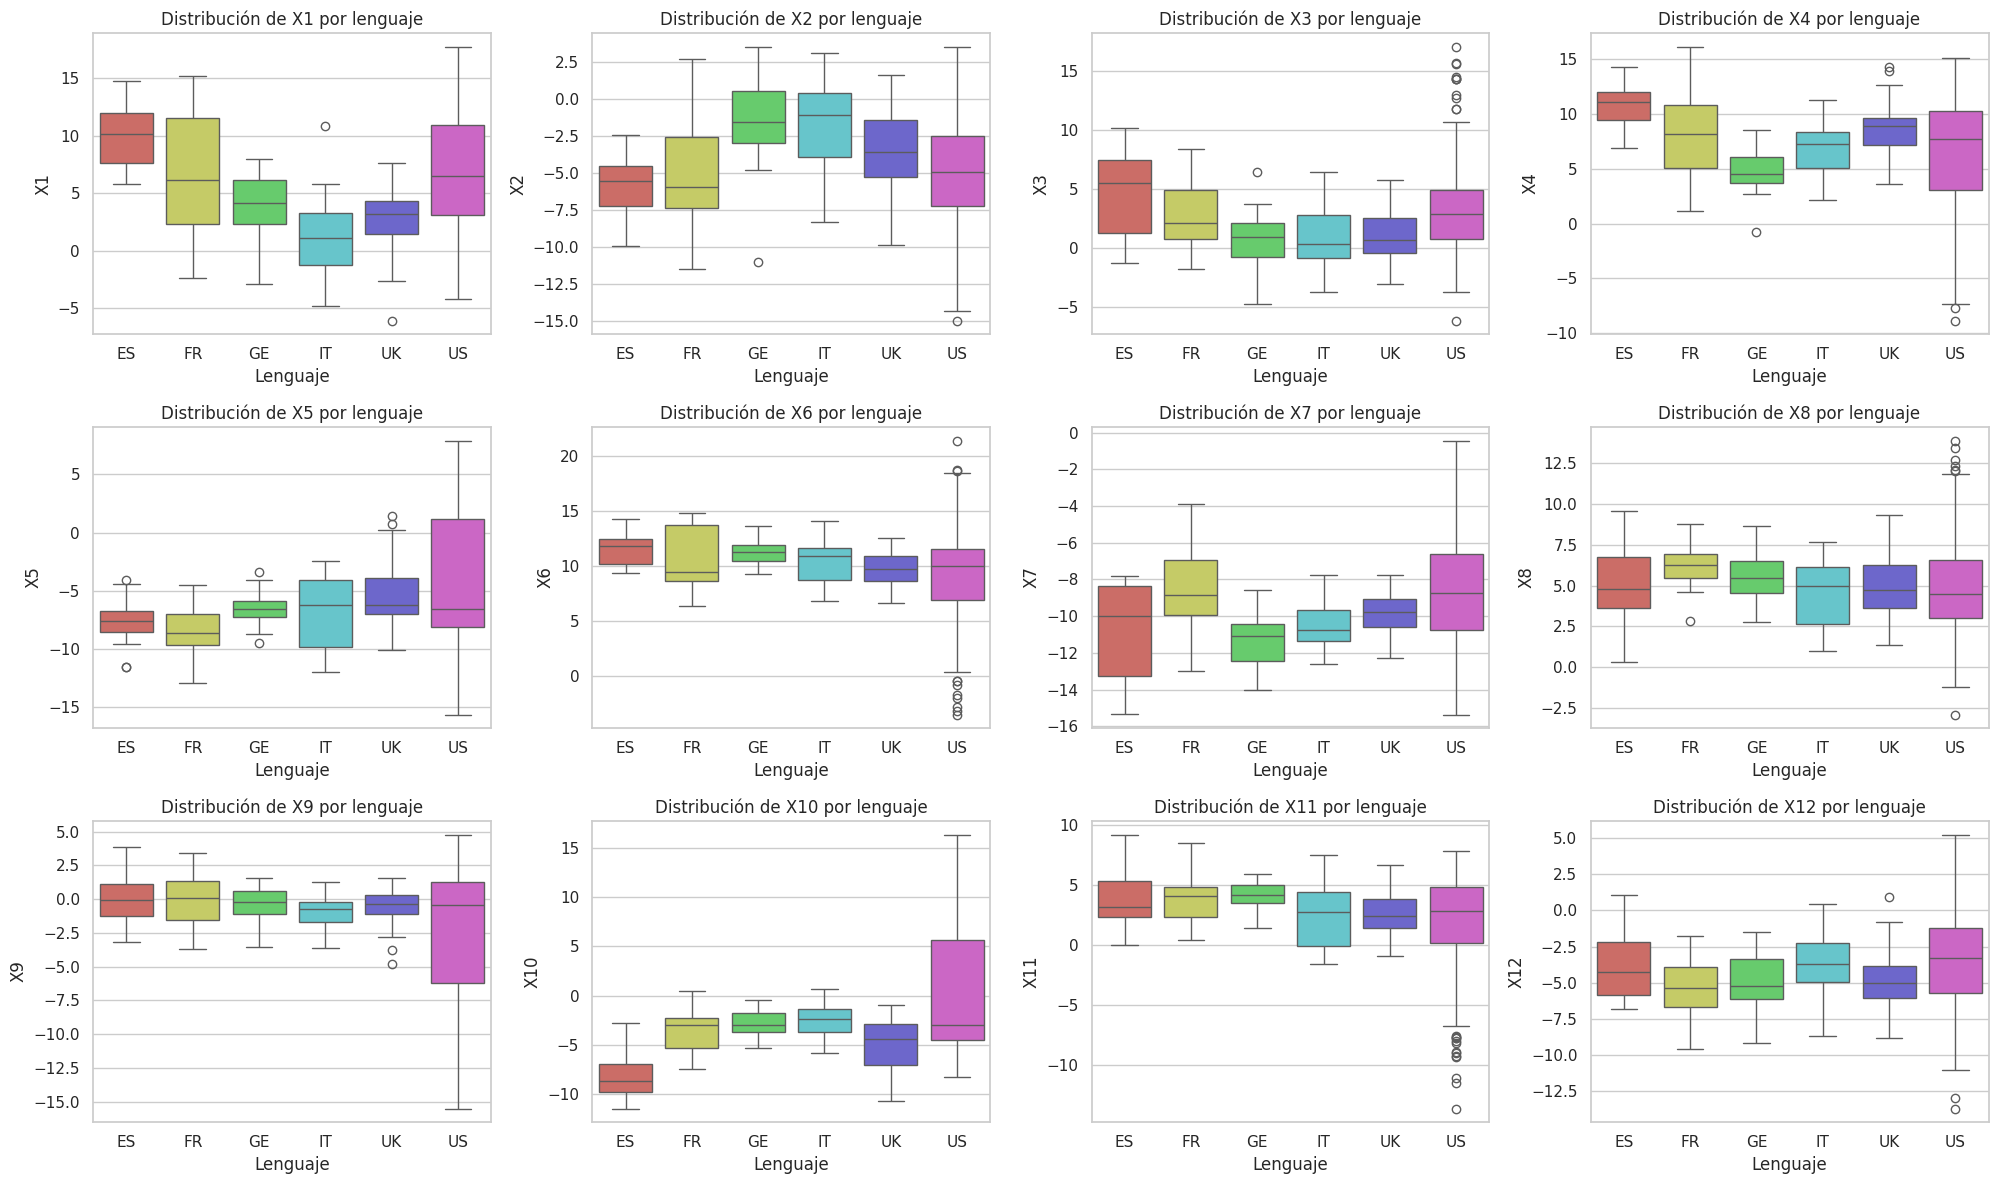

In [ ]:
# Características a analizar
variables = [col for col in df.columns if col.startswith("X")]

sns.set(style="whitegrid")

# Crear subplots: uno por variable
n_cols = 4
n_rows = (len(variables) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.boxplot(data=df, x="language", y=var, ax=axes[i], palette="hls")
    axes[i].set_title(f"Distribución de {var} por lenguaje", fontsize=12)
    axes[i].set_xlabel("Lenguaje")
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()


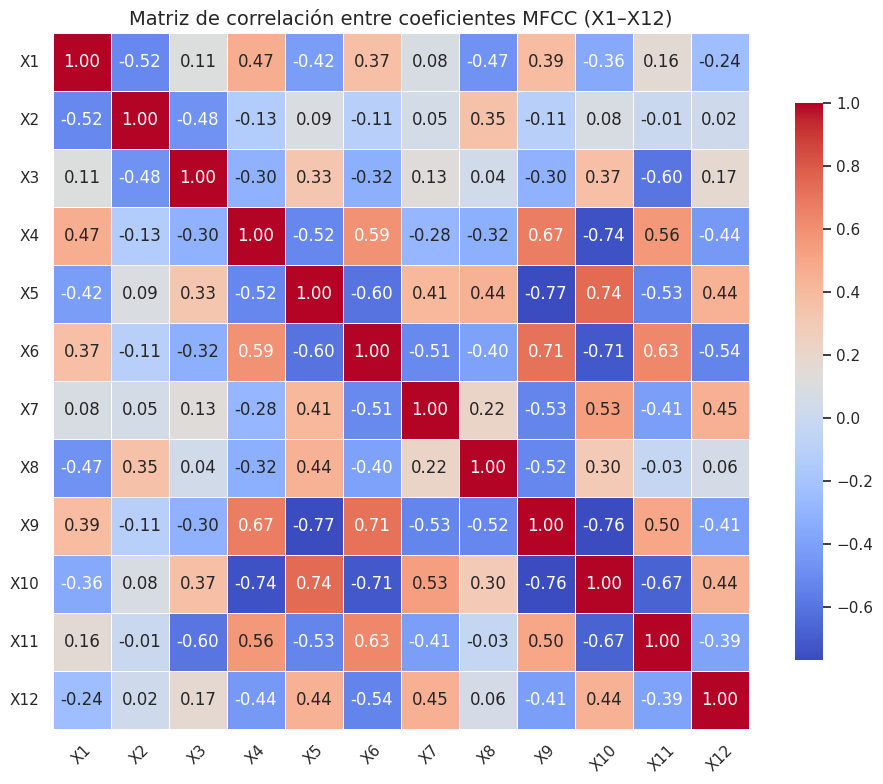

In [ ]:
# Supongamos que tu DataFrame se llama df
mfcc_columns = [f'X{i}' for i in range(1, 13)]
mfcc_data = df[mfcc_columns]

# Calcular la matriz de correlación
corr_matrix = mfcc_data.corr()

# Dibujar el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"shrink": .8}, linewidths=0.5)

plt.title("Matriz de correlación entre coeficientes MFCC (X1–X12)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


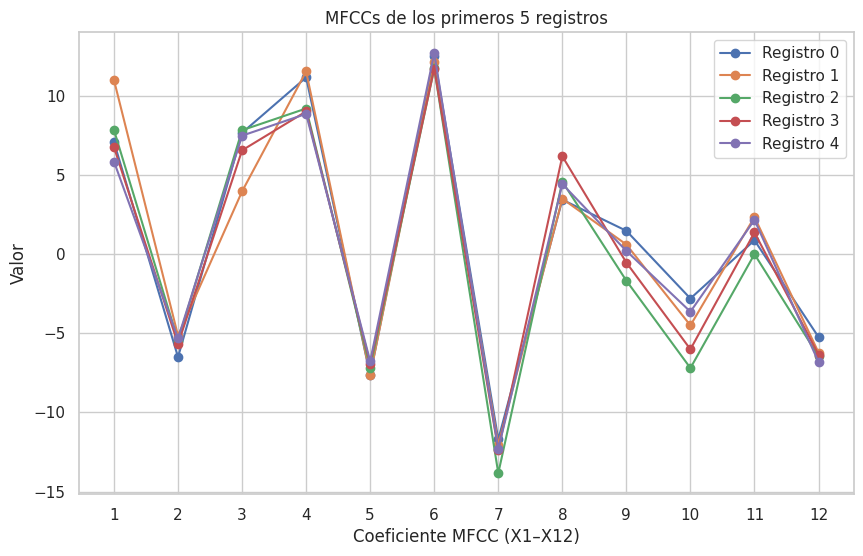

In [ ]:
# Tomar las primeras 5 filas
df_subset = df.head(5)

# Solo columnas X1 a X12
mfcc_columns = [f'X{i}' for i in range(1, 13)]
mfcc_data = df_subset[mfcc_columns].to_numpy()

# Graficar
plt.figure(figsize=(10, 6))
for i, row in enumerate(mfcc_data):
    plt.plot(range(1, 13), row, marker='o', label=f'Registro {i}')
plt.title('MFCCs de los primeros 5 registros')
plt.xlabel('Coeficiente MFCC (X1–X12)')
plt.ylabel('Valor')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()


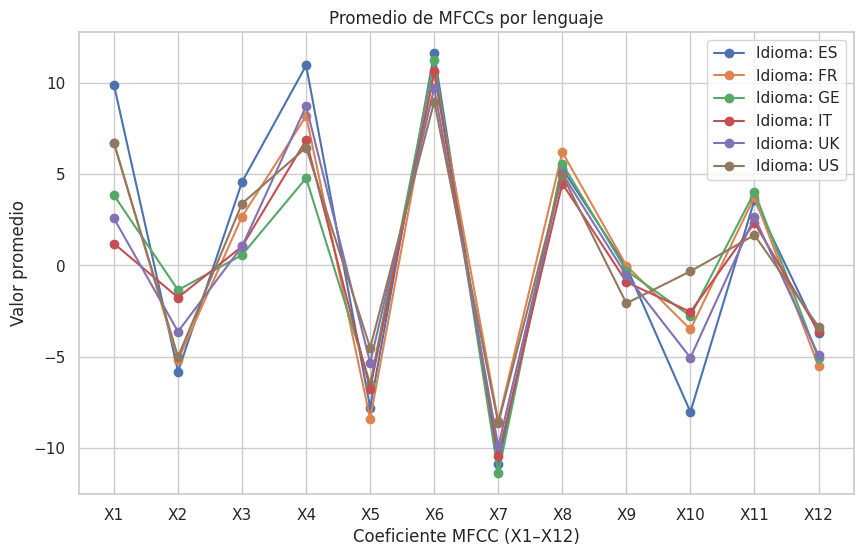

In [ ]:
# Suponiendo que df ya está cargado y contiene la columna 'language' y X1–X12
mfcc_columns = [f'X{i}' for i in range(1, 13)]

# Calcular promedio por lenguaje
mean_by_language = df.groupby("language")[mfcc_columns].mean()

# Graficar
plt.figure(figsize=(10, 6))
for lang in mean_by_language.index:
    plt.plot(range(1, 13), mean_by_language.loc[lang], marker='o', label=f'Idioma: {lang}')

plt.title('Promedio de MFCCs por lenguaje')
plt.xlabel('Coeficiente MFCC (X1–X12)')
plt.ylabel('Valor promedio')
plt.xticks(range(1, 13), [f'X{i}' for i in range(1, 13)])
plt.legend()
plt.grid(True)
plt.show()


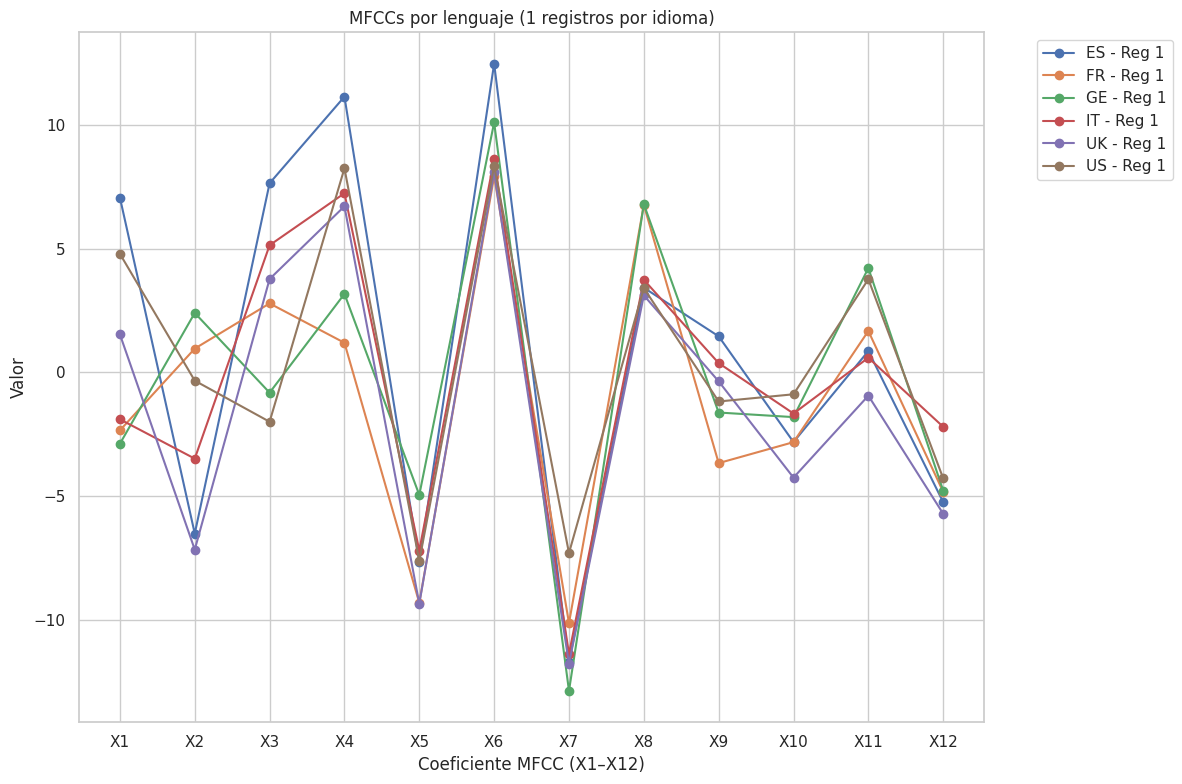

In [ ]:
plt.figure(figsize=(12, 8))

languages = df['language'].unique()
mfcc_columns = [f'X{i}' for i in range(1, 13)]

for lang in languages:
    # Tomar los primeros 5 registros por lenguaje
    subset = df[df['language'] == lang].head(1)[mfcc_columns].to_numpy()
    for i, row in enumerate(subset):
        plt.plot(range(1, 13), row, marker='o', label=f'{lang} - Reg {i+1}')

plt.title('MFCCs por lenguaje (1 registros por idioma)')
plt.xlabel('Coeficiente MFCC (X1–X12)')
plt.ylabel('Valor')
plt.xticks(range(1, 13), [f'X{i}' for i in range(1, 13)])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# Limpieza del dataset


Datos nulos por caracteristica
language    0
X1          0
X2          0
X3          0
X4          0
X5          0
X6          0
X7          0
X8          0
X9          0
X10         0
X11         0
X12         0
dtype: int64

 Tipos de las variables
language     object
X1          float64
X2          float64
X3          float64
X4          float64
X5          float64
X6          float64
X7          float64
X8          float64
X9          float64
X10         float64
X11         float64
X12         float64
dtype: object

Distribucion de las clases
language
US    165
UK     45
IT     30
FR     30
GE     30
ES     29
Name: count, dtype: int64

Distribucion de las clases por porcentajes
language
US    0.5015
UK    0.1368
IT    0.0912
FR    0.0912
GE    0.0912
ES    0.0881
Name: proportion, dtype: float64

 Desviacion estandar por caracteristica
X1     5.1053
X2     3.5143
X3     3.6353
X4     4.3101
X5     4.5962
X6     3.6247
X7     2.4841
X8     2.6506
X9     3.6348
X10    5.0420
X11    

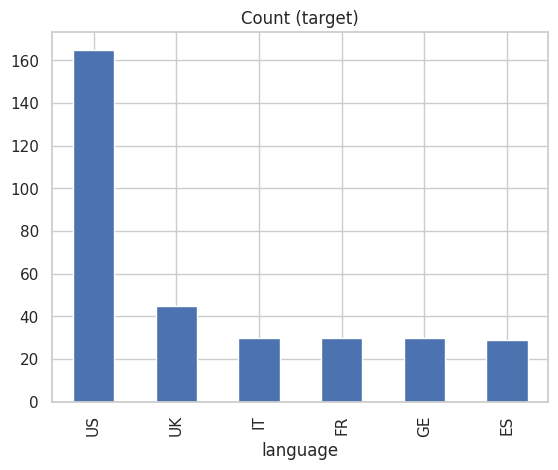

In [ ]:
print("Datos nulos por caracteristica")
#Comprobar que no hay nulos
print(df.isnull().sum())

print("\n Tipos de las variables")
#Ver los tipos de las Variables
print(df.dtypes)

print("\n Desviacion estandar por caracteristica")
"Ver la desviacion estandar para cada feature"
df_std = df.copy()
df_std = df_std.iloc[:, 1:].std()
print(df_std)

In [ ]:
df_numeric = df.select_dtypes(include=np.number)

for column_name in df_numeric.columns:
    k2, p = stats.normaltest(df_numeric[column_name])
    alpha = 0.05  # Nivel de significancia
    print(f"--- Característica: {column_name} ---")
    if p < alpha:  # Hipótesis nula: los datos provienen de una distribución normal
        print("La hipótesis nula se rechaza -> NO es una distribución normal.")
    else:
        print("La hipótesis nula no se puede rechazar -> SÍ podría ser una distribución normal.")
    print(f"(p-value: {p:.4f})\n")

--- Característica: X1 ---
La hipótesis nula se rechaza -> NO es una distribución normal.
(p-value: 0.0002)

--- Característica: X2 ---
La hipótesis nula no se puede rechazar -> SÍ podría ser una distribución normal.
(p-value: 0.1976)

--- Característica: X3 ---
La hipótesis nula se rechaza -> NO es una distribución normal.
(p-value: 0.0000)

--- Característica: X4 ---
La hipótesis nula se rechaza -> NO es una distribución normal.
(p-value: 0.0000)

--- Característica: X5 ---
La hipótesis nula se rechaza -> NO es una distribución normal.
(p-value: 0.0000)

--- Característica: X6 ---
La hipótesis nula se rechaza -> NO es una distribución normal.
(p-value: 0.0000)

--- Característica: X7 ---
La hipótesis nula se rechaza -> NO es una distribución normal.
(p-value: 0.0012)

--- Característica: X8 ---
La hipótesis nula se rechaza -> NO es una distribución normal.
(p-value: 0.0015)

--- Característica: X9 ---
La hipótesis nula se rechaza -> NO es una distribución normal.
(p-value: 0.0000)

-

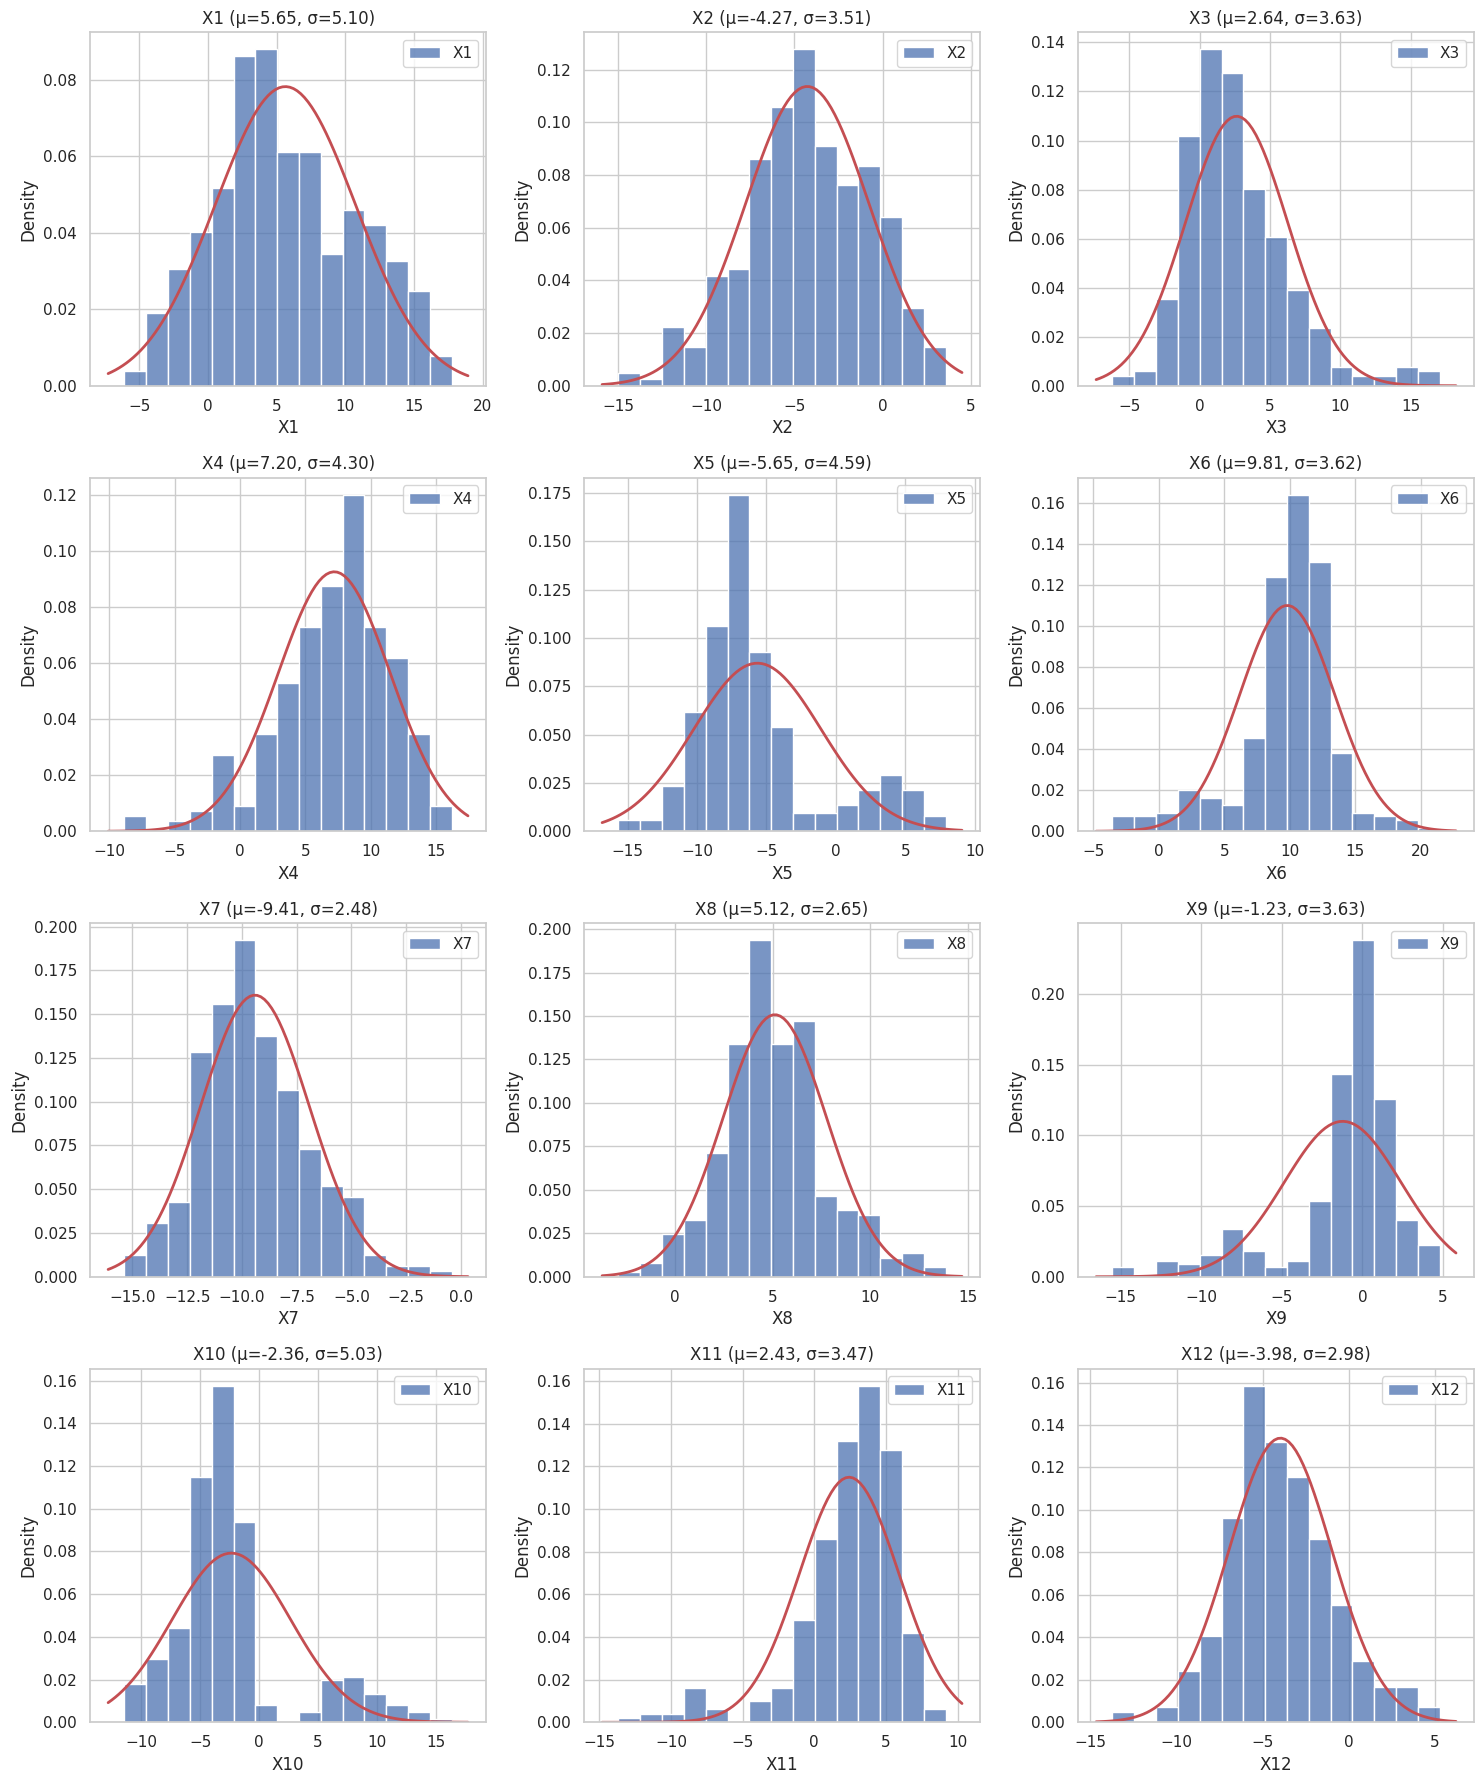

In [ ]:
plt.figure(figsize=(15, 18))
try:
    for i, col in enumerate(df_numeric.columns):
        plt.subplot(4, 3, i + 1)
        sns.histplot(df_numeric[col], bins=15, stat='density', kde=False, label=col)

        # Ajuste normal
        mu, std = norm.fit(df_numeric[col].dropna())
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        plt.plot(x, p, 'r', linewidth=2)

        plt.legend()
        plt.title(f"{col} (μ={mu:.2f}, σ={std:.2f})")
        plt.tight_layout()
except Exception as e:
    print(f"Error en columna {col}: {e}")

# 4. Entrenamiento y Evaluación de los Modelos

Distribución de clases:
binary_target
1    165
0    164
Name: count, dtype: int64

Accuracy del modelo: 0.8384 

Reporte de Clasificación:
              precision    recall  f1-score   support

   No US (0)       0.81      0.88      0.84        49
      US (1)       0.87      0.80      0.83        50

    accuracy                           0.84        99
   macro avg       0.84      0.84      0.84        99
weighted avg       0.84      0.84      0.84        99



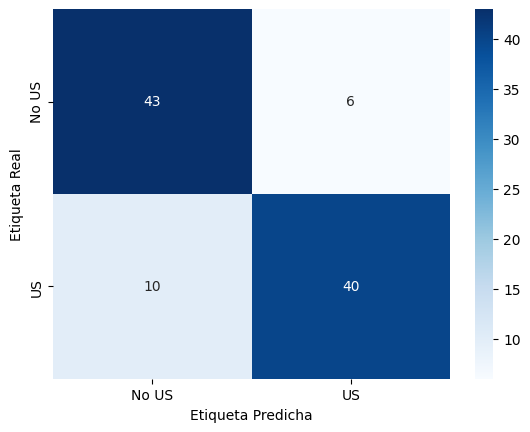

In [ ]:
url = 'https://raw.githubusercontent.com/BrahianCarrera/Speaker-Recognition/main/dataset/accent-mfcc-data-1.csv'
df = pd.read_csv(url)

# Crear la variable objetivo binaria: 1 para 'US', 0 para 'No US'
df['binary_target'] = np.where(df['language'] == 'US', 1, 0)

# Separar características (X) y labels (y)
X = df.drop(['language', 'binary_target'], axis=1)
y = df['binary_target']

print("Distribución de clases:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalar las características (muy importante para muchos modelos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=32, class_weight='balanced')
model.fit(X_train_scaled, y_train)

#evaluar
y_pred = model.predict(X_test_scaled)

# Calcular y mostrar la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy del modelo: {accuracy:.4f} ")

#Reporte
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No US (0)', 'US (1)']))

# Mostrar la matriz de confusión para ver los errores
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No US', 'US'], yticklabels=['No US', 'US'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()



## 4.1. Configuración experimental

### 5. Describa la metodología de validación escogida para entrenar y evaluar los modelos de ML. En caso de requerir etapas adicionales, como la utilización de técnicas de sub o sobremuestreo, la forma en la que fueron usadas debe estar descrita en este apartado.

### Metodología de validación

Para entrenar y evaluar los modelos de Machine Learning, se empleará la **validación cruzada estratificada (Stratified K-Fold Cross-Validation)** con $k=5$ folds. Esta técnica es fundamental dado el desbalance de clases identificado en el dataset, ya que garantiza que la proporción de cada clase se mantenga de manera similar en cada fold de entrenamiento y validación. Esto ayuda a obtener estimaciones más fiables del desempeño del modelo en comparación con la validación cruzada simple.

Adicionalmente, para mitigar el efecto del desbalance de clases en la fase de entrenamiento, se aplicará la técnica de **sobremuestreo SMOTE (Synthetic Minority Over-sampling Technique)** a los datos de entrenamiento en cada fold. SMOTE generará instancias sintéticas para las clases minoritarias, equilibrando así la distribución de clases en el conjunto de entrenamiento antes de entrenar cada modelo. La evaluación del modelo se realizará sobre el conjunto de validación original (sin sobremuestreo) de cada fold.

SMOTE debe aplicarse solo a los datos de entrenamiento dentro de cada fold de la validación cruzada. Si aplicamos SMOTE al conjunto de datos completo antes de dividirlo, estaríamos creando instancias sintéticas basándonos en información de los datos de validación, lo que resultaría en una fuga de datos (data leakage). Esto llevaría a una sobreestimación del rendimiento del modelo en datos no vistos.

In [ ]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
0,7.0715,-6.5129,7.6508,11.1508,-7.6573,12.4840,-11.7098,3.4266,1.4627,-2.8128,0.8665,-5.2443
1,10.9830,-5.1574,3.9521,11.5294,-7.6380,12.1361,-12.0362,3.4919,0.5954,-4.5088,2.3321,-6.2219
2,7.8271,-5.4775,7.8163,9.1876,-7.1725,11.7153,-13.8472,4.5741,-1.6876,-7.2040,-0.0118,-6.4631
3,6.7441,-5.6889,6.5468,9.0002,-6.9250,11.7108,-12.3744,6.1699,-0.5447,-6.0192,1.3586,-6.3564
4,5.8368,-5.3266,7.4723,8.8474,-6.7732,12.6772,-12.3151,4.4163,0.1935,-3.6448,2.1512,-6.8163


In [ ]:
# Separar características (X) y variable objetivo (y)
X = df.drop(['language', 'binary_target'], axis=1)
y_series = df['language'] # Mantén una referencia a la serie original si necesitas los nombres de las clases más tarde

le = LabelEncoder()
y = le.fit_transform(y_series)

# Convertir 'y' de nuevo a una Serie de Pandas después de la codificación
# Esto permite el uso consistente de .iloc con X
y = pd.Series(y, index=y_series.index, name='language')

# Configurar la validación cruzada estratificada
# Usaremos 5 folds como ejemplo
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Preparar para almacenar índices de train y validation para cada fold
train_indices = []
val_indices = []

# Aplicar StratifiedKFold y almacenar los índices
for train_index, val_index in skf.split(X, y):
    train_indices.append(train_index)
    val_indices.append(val_index)

print(f"Se configuró la validación cruzada estratificada con {n_splits} folds.")
print("Los índices de entrenamiento y validación para cada fold están almacenados en 'train_indices' y 'val_indices'.")
print("Estos índices se utilizarán para dividir los datos en cada iteración de la validación cruzada.")

Se configuró la validación cruzada estratificada con 5 folds.
Los índices de entrenamiento y validación para cada fold están almacenados en 'train_indices' y 'val_indices'.
Estos índices se utilizarán para dividir los datos en cada iteración de la validación cruzada.


In [8]:
y.unique()

array([0, 1, 2, 3, 4, 5])

In [ ]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
0,7.0715,-6.5129,7.6508,11.1508,-7.6573,12.4840,-11.7098,3.4266,1.4627,-2.8128,0.8665,-5.2443
1,10.9830,-5.1574,3.9521,11.5294,-7.6380,12.1361,-12.0362,3.4919,0.5954,-4.5088,2.3321,-6.2219
2,7.8271,-5.4775,7.8163,9.1876,-7.1725,11.7153,-13.8472,4.5741,-1.6876,-7.2040,-0.0118,-6.4631
3,6.7441,-5.6889,6.5468,9.0002,-6.9250,11.7108,-12.3744,6.1699,-0.5447,-6.0192,1.3586,-6.3564
4,5.8368,-5.3266,7.4723,8.8474,-6.7732,12.6772,-12.3151,4.4163,0.1935,-3.6448,2.1512,-6.8163


### 6. Incluya una tabla en la que especifique el conjunto de hiperparámetros que fueron analizados durante el proceso de evaluación de cada modelo, junto con la descripción de la malla de valores usada para cada uno. Cada proyecto debe comparar al menos 5 modelos de aprendizaje, entre los que se deben incluir:

- Un modelo paramétrico basado en funciones discriminantes gaussianas o en regresión (lineal o logística según se requiera).
- Un modelo no paramétrico
- Un modelo basado en el ensamble de árboles de decisión
- Una red neuronal artificial
- Una máquina de vectores de soporte.

### Modelos y malla de hiperparámetros

Para la tarea de clasificación de acentos, se seleccionaron 5 modelos de Machine Learning que abarcan diferentes enfoques de modelado. Para cada modelo, se define una malla de hiperparámetros a explorar mediante búsqueda en cuadrícula (Grid Search) dentro del proceso de validación cruzada. La combinación óptima de hiperparámetros se determinará en base a las métricas de desempeño definidas en el siguiente apartado.

A continuación, se detallan los modelos y sus respectivas mallas de hiperparámetros:

**1. Modelo Paramétrico: Regresión Logística (Logistic Regression)**

Un modelo lineal que utiliza una función logística para modelar la probabilidad de pertenencia a una clase. Es adecuado como línea base paramétrica.

| Hiperparámetro | Descripción                                                                 | Malla de Valores Explorados                      |
| :------------- | :-------------------------------------------------------------------------- | :----------------------------------------------- |
| `C`            | Inverso de la fuerza de regularización. Valores más pequeños especifican una regularización más fuerte. | `[0.001, 0.01, 0.1, 1, 10, 100]`               |
| `solver`       | Algoritmo a usar en el problema de optimización.                            | `['liblinear', 'lbfgs']`                         |
| `penalty`      | Especifica la norma utilizada en la penalización (`'l1'`, `'l2'`, `'elasticnet'`, `'none'`). | `['l2']` (Se ajusta a los solvers elegidos)     |

**2. Modelo No Paramétrico: K-Vecinos Más Cercanos (K-Nearest Neighbors)**

Un modelo simple basado en la distancia que clasifica un punto de datos en función de la clase de sus 'k' vecinos más cercanos en el espacio de características.

| Hiperparámetro     | Descripción                                                                 | Malla de Valores Explorados |
| :----------------- | :-------------------------------------------------------------------------- | :-------------------------- |
| `n_neighbors`      | Número de vecinos a considerar.                                             | `[3, 5, 7, 9]`              |
| `weights`          | Función de peso utilizada en la predicción.                                 | `['uniform', 'distance']`   |
| `p`                | Parámetro de potencia para la métrica de Minkowski. `p=1` para Manhanttan, `p=2` para Euclidiana. | `[1, 2]`                   |

**3. Ensamble de Árboles de Decisión: Random Forest**

Un modelo de ensamble que construye múltiples árboles de decisión durante el entrenamiento y produce la clase que es la moda de las clases de los árboles individuales (para clasificación).

| Hiperparámetro      | Descripción                                                                 | Malla de Valores Explorados          |
| :------------------ | :-------------------------------------------------------------------------- | :----------------------------------- |
| `n_estimators`      | Número de árboles en el bosque.                                             | `[50, 100, 200]`                     |
| `max_depth`         | Profundidad máxima del árbol. `None` expande nodos hasta que todas las hojas son puras o contienen menos muestras que `min_samples_split`. | `[None, 10, 20]`                     |
| `min_samples_split` | Número mínimo de muestras requeridas para dividir un nodo interno.            | `[2, 5, 10]`                         |
| `min_samples_leaf`  | Número mínimo de muestras requeridas para estar en un nodo hoja.              | `[1, 2, 4]`                          |

**4. Red Neuronal Artificial: Multi-layer Perceptron (MLPClassifier)**

Un modelo de red neuronal simple con al menos una capa oculta no lineal.

| Hiperparámetro         | Descripción                                                                 | Malla de Valores Explorados                      |
| :--------------------- | :-------------------------------------------------------------------------- | :----------------------------------------------- |
| `hidden_layer_sizes`   | El tamaño de las capas ocultas en la red neuronal.                          | `[(50,), (100,), (50, 50), (100, 50)]`            |
| `activation`           | Función de activación para las capas ocultas.                               | `['tanh', 'relu']`                               |
| `solver`               | El solver para la optimización de los pesos.                                | `['adam', 'sgd']`                                |
| `alpha`                | Parámetro de penalización (regularización L2) del término de la función de pérdida. | `[0.0001, 0.001, 0.01]`                          |
| `learning_rate_init`   | Tasa de aprendizaje inicial utilizada para 'sgd'.                           | `[0.001]` (Para simplificar, si se usa 'sgd') |


**5. Máquina de Vectores de Soporte (Support Vector Machine): SVC**

Un modelo que busca el hiperplano que mejor separa las clases en el espacio de características.

| Hiperparámetro | Descripción                                                                 | Malla de Valores Explorados          |
| :------------- | :-------------------------------------------------------------------------- | :----------------------------------- |
| `C`            | Parámetro de regularización. La fuerza de la regularización es inversamente proporcional a C. | `[0.1, 1, 10]`                       |
| `kernel`       | Especifica el tipo de kernel a utilizar en el algoritmo.                    | `['linear', 'rbf']`                  |
| `gamma`        | Coeficiente del kernel para 'rbf', 'poly' y 'sigmoid'.                      | `['scale', 'auto']`                  |

 la "malla de valores" son las opciones que le damos a Grid Search para que este explore y encuentre la mejor configuración ("los mejores hiperparámetros") para cada modelo.

### 7. Describa cuáles serán las métricas de desempeño que se usarán para evaluar el sistema y justifique su utilización.

### Métricas de desempeño

Dado el desbalance de clases en nuestro dataset, usaremos métricas que van más allá de la precisión general para entender mejor el rendimiento del modelo en cada tipo de acento. Las métricas seleccionadas son:

1.  **Matriz de Confusión:**
    *   **Descripción:** Una tabla que muestra cuántas veces el modelo clasificó correctamente o incorrectamente cada acento.
    *   **Justificación:** Ayuda a ver si el modelo confunde ciertos acentos y cómo maneja las clases con menos datos.

2.  **Precisión (Precision) por clase y macro-promedio:**
    *   **Descripción:** Mide qué tan correctas son las predicciones positivas para cada acento. El macro-promedio da igual peso a cada acento.
    *   **Justificación:** Nos dice si cuando el modelo predice un acento, realmente es ese acento. Útil para evitar muchos falsos positivos.

3.  **Recall (Sensibilidad o Exhaustividad) por clase y macro-promedio:**
    *   **Descripción:** Mide cuántos de cada acento real el modelo fue capaz de identificar. El macro-promedio da igual peso a cada acento.
    *   **Justificación:** Nos dice si el modelo es bueno encontrando todas las instancias de cada acento, importante para no dejar pasar acentos minoritarios (pocos datos).

4.  **Puntuación F1 (F1-score) por clase y macro-promedio:**
    *   **Descripción:** Combina Precisión y Recall en una sola métrica, buscando un equilibrio entre ambas. El macro-promedio da igual peso a cada acento.
    *   **Justificación:** Es una métrica robusta para datasets desbalanceados, ya que un buen F1 requiere tanto buena precisión como buen recall. El macro-promedio resume el rendimiento general considerando el desbalance.

Estas métricas nos darán una evaluación completa y justa del rendimiento de los modelos, prestando especial atención a cómo manejan los diferentes acentos, incluyendo aquellos con menos ejemplos.

En Machine Learning, determinar si un modelo es "bueno" o "malo" basándose solo en un umbral fijo para métricas como F1-score, precisión o recall es complicado y a menudo depende del contexto específico del problema y de lo que se considere aceptable.

En lugar de definir un umbral rígido, lo más común es:

Comparar el rendimiento de los diferentes modelos entre sí: El objetivo principal de este ejercicio es comparar cómo se desempeñan los 5 modelos seleccionados y encontrar la mejor combinación de hiperparámetros para cada uno dentro de la malla definida. Un modelo es "mejor" si consistentemente obtiene métricas más altas que otros modelos en la validación cruzada.
Establecer una línea base (baseline): A menudo se entrena un modelo muy simple (como un clasificador aleatorio o un modelo paramétrico básico sin ajuste de hiperparámetros) para tener una referencia. Los modelos más complejos deberían superar significativamente esta línea base para considerarse útiles.
Considerar las necesidades del problema: Lo que se considera "bueno" o "malo" también depende de las implicaciones de los errores de clasificación en el problema real. Por ejemplo, en algunas aplicaciones, tener falsos positivos puede ser más costoso que tener falsos negativos (o viceversa). Las métricas por clase (precisión por clase, recall por clase) te ayudarán a entender este aspecto.
Observar los intervalos de confianza: La desviación estándar que calcularemos te dará una idea de la variabilidad del rendimiento del modelo a través de los diferentes folds. Un modelo con un rendimiento promedio alto pero una desviación estándar muy grande podría ser menos fiable que un modelo con un rendimiento promedio ligeramente menor pero una desviación estándar baja.
En resumen, en lugar de buscar un umbral único de "bien o mal", nos enfocaremos en comparar el rendimiento relativo de los modelos utilizando las métricas elegidas y sus intervalos de confianza, y consideraremos las implicaciones de las métricas por clase para entender el desempeño en cada acento.

## 4.2. Resultados del entrenamiento de Modelos

### 8. Presente los resultados de la experimentación para cada uno de los modelos evaluados, en los que se evidencie el efecto de los hiperparámetros en el desempeño del modelo. Haga uso de tablas y gráficas que ayuden al lector a comprender de manera clara los resultados. TODAS las figuras y tablas deben ser introducidas en el texto del informe y contener un caption que las describa. Todas las figuras deben incluir el nombre de los ejes para que el lector pueda comprender la información que se le presenta. Las medidas de desempeño deben incluir los correspondientes intervalos de confianza estimados durante la fase de validación.

Recuerde incluir resultados de entrenamiento, validación y test.


In [ ]:
warnings.filterwarnings('ignore')

# Separar características (X) y variable objetivo (y)
X = df.drop(['language', 'binary_target'], axis=1)
y_series = df['language'] # Mantén una referencia a la serie original si necesitas los nombres de las clases más tarde

le = LabelEncoder()
y = le.fit_transform(y_series)

# Convertir 'y' de nuevo a una Serie de Pandas después de la codificación
# Esto permite el uso consistente de .iloc con X
y = pd.Series(y, index=y_series.index, name='language')

# Configurar la validación cruzada estratificada
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# ... (el resto de tu código es el mismo) ...

# Definir los modelos y sus mallas de hiperparámetros
models_and_hyperparameters = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs'],
            'penalty': ['l2']
        }
    },
    'KNeighborsClassifier': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'MLPClassifier': {
        'model': MLPClassifier(max_iter=1000, random_state=42),
        'params': {
            'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
            'activation': ['tanh', 'relu'],
            'solver': ['adam', 'sgd'],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate_init': [0.001]
        }
    },
    'SVC': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    }
}

# Inicializar SMOTE
smote = SMOTE(random_state=42)

# Diccionario para almacenar los resultados de todos los modelos y sus hiperparámetros
results = {}

# Iterar sobre cada modelo
for model_name, config in models_and_hyperparameters.items():
    print(f"Entrenando y evaluando {model_name}...")

    model = config['model']
    param_grid = config['params']
    model_results = {}

    # Iterar sobre cada combinación de hiperparámetros
    from sklearn.model_selection import ParameterGrid
    param_combinations = list(ParameterGrid(param_grid))

    for params in param_combinations:
        print(f"   Probando hiperparámetros: {params}")
        model.set_params(**params)

        fold_metrics = {
            'f1_macro': [],
            'precision_macro': [],
            'recall_macro': [],
            'f1_per_class': [],
            'precision_per_class': [],
            'recall_per_class': []
        }

        # Realizar validación cruzada estratificada
        for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]

            # Aplicar SMOTE solo en el conjunto de entrenamiento del fold actual
            X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

            # Entrenar el modelo
            model.fit(X_train_resampled, y_train_resampled)

            # Predecir en el conjunto de validación (sin SMOTE)
            y_pred = model.predict(X_val)

            # Calcular métricas de desempeño
            fold_metrics['f1_macro'].append(f1_score(y_val, y_pred, average='macro'))
            fold_metrics['precision_macro'].append(precision_score(y_val, y_pred, average='macro'))
            fold_metrics['recall_macro'].append(recall_score(y_val, y_pred, average='macro'))

            # Calcular métricas por clase y almacenar
            # Asegúrate de que y.unique() funcione correctamente con los valores numéricos de y
            # Si necesitas los nombres de las clases originales para el reporte, puedes usar le.inverse_transform
            report = classification_report(y_val, y_pred, output_dict=True, target_names=le.classes_)
            fold_metrics['f1_per_class'].append({label: report[label]['f1-score'] for label in le.classes_})
            fold_metrics['precision_per_class'].append({label: report[label]['precision'] for label in le.classes_})
            fold_metrics['recall_per_class'].append({label: report[label]['recall'] for label in le.classes_})


        # Calcular promedio y desviación estándar de las métricas para esta combinación de hiperparámetros
        avg_metrics = {metric: np.mean(values) for metric, values in fold_metrics.items() if 'per_class' not in metric}
        std_metrics = {metric: np.std(values) for metric, values in fold_metrics.items() if 'per_class' not in metric}

        # Calcular promedio y desviación estándar para métricas por clase
        avg_metrics_per_class = {}
        std_metrics_per_class = {}
        for metric_type in ['f1', 'precision', 'recall']:
            metric_name = f'{metric_type}_per_class'
            if fold_metrics[metric_name]:
                metrics_by_class = {label: [d[label] for d in fold_metrics[metric_name]] for label in le.classes_} # Usar le.classes_ aquí
                avg_metrics_per_class[metric_type] = {label: np.mean(values) for label, values in metrics_by_class.items()}
                std_metrics_per_class[metric_type] = {label: np.std(values) for label, values in metrics_by_class.items()}


        model_results[str(params)] = {
            'fold_metrics': fold_metrics,
            'avg_metrics': avg_metrics,
            'std_metrics': std_metrics,
            'avg_metrics_per_class': avg_metrics_per_class,
            'std_metrics_per_class': std_metrics_per_class
        }

    results[model_name] = model_results

print("\nEntrenamiento y evaluación completados.")

Entrenando y evaluando LogisticRegression...
   Probando hiperparámetros: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
   Probando hiperparámetros: {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
   Probando hiperparámetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
   Probando hiperparámetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
   Probando hiperparámetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
   Probando hiperparámetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
   Probando hiperparámetros: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
   Probando hiperparámetros: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
   Probando hiperparámetros: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
   Probando hiperparámetros: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
   Probando hiperparámetros: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
   Probando hiperparámetros: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Entrenando y evalua

### Análisis de Resultados por Modelo

A continuación, se presentan los resultados de la validación cruzada estratificada con SMOTE para cada modelo evaluado y las diferentes combinaciones de hiperparámetros. Las tablas muestran el promedio y la desviación estándar de las métricas macro (F1, Precision, Recall) obtenidas a través de los 5 folds.

**Nota:** La desviación estándar ($\pm$ valor) indica la variabilidad del rendimiento a través de los diferentes folds de validación cruzada. Un valor más bajo sugiere un rendimiento más consistente.


#### Análisis de Logistic Regression

Observando los resultados para Logistic Regression:

In [ ]:
model_name = 'LogisticRegression'
model_results = results[model_name]

data = []
for params, metrics in model_results.items():
    row = {'Hyperparameters': params}
    for metric_name, value in metrics['avg_metrics'].items():
        std_dev = metrics['std_metrics'][metric_name]
        row[metric_name] = f"{value:.4f} $\pm$ {std_dev:.4f}"
    data.append(row)

df_results = pd.DataFrame(data)
print(f"Resultados de la validación cruzada para {model_name}:")
display(df_results)

# Identificar la mejor combinación basada en f1_macro
best_params_lr = None
best_f1_lr = -1
for params_str, metrics in model_results.items():
    if metrics['avg_metrics']['f1_macro'] > best_f1_lr:
        best_f1_lr = metrics['avg_metrics']['f1_macro']
        best_params_lr = params_str

print(f"\nMejor combinación de hiperparámetros para {model_name} (basado en f1_macro promedio):")
print(best_params_lr)
print(f"F1-macro promedio: {best_f1_lr:.4f} $\pm$ {model_results[best_params_lr]['std_metrics']['f1_macro']:.4f}")

Resultados de la validación cruzada para LogisticRegression:


,Hyperparameters,f1_macro,precision_macro,recall_macro
0,"{'C': 0.001, 'penalty': 'l2', 'solver': 'libli...",0.5285 $\pm$ 0.0597,0.5518 $\pm$ 0.0597,0.6380 $\pm$ 0.0382
1,"{'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}",0.5941 $\pm$ 0.0397,0.5834 $\pm$ 0.0431,0.6877 $\pm$ 0.0278
2,"{'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...",0.5883 $\pm$ 0.0370,0.5768 $\pm$ 0.0351,0.6746 $\pm$ 0.0354
3,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.6295 $\pm$ 0.0220,0.6058 $\pm$ 0.0197,0.7031 $\pm$ 0.0242
4,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.5977 $\pm$ 0.0422,0.5812 $\pm$ 0.0429,0.6866 $\pm$ 0.0357
5,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.6524 $\pm$ 0.0349,0.6367 $\pm$ 0.0317,0.7145 $\pm$ 0.0359
6,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.6129 $\pm$ 0.0418,0.5956 $\pm$ 0.0437,0.6979 $\pm$ 0.0380
7,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.6585 $\pm$ 0.0368,0.6533 $\pm$ 0.0425,0.7147 $\pm$ 0.0235
8,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}",0.6403 $\pm$ 0.0228,0.6247 $\pm$ 0.0262,0.7107 $\pm$ 0.0293
9,"{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}",0.6366 $\pm$ 0.0365,0.6287 $\pm$ 0.0430,0.6905 $\pm$ 0.0339



Mejor combinación de hiperparámetros para LogisticRegression (basado en f1_macro promedio):
{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
F1-macro promedio: 0.6585 $\pm$ 0.0368


#### Análisis de K-Neighbors Classifier

Observando los resultados para K-Neighbors Classifier:

In [ ]:
model_name = 'KNeighborsClassifier'
model_results = results[model_name]

data = []
for params, metrics in model_results.items():
    row = {'Hyperparameters': params}
    for metric_name, value in metrics['avg_metrics'].items():
        std_dev = metrics['std_metrics'][metric_name]
        row[metric_name] = f"{value:.4f} $\pm$ {std_dev:.4f}"
    data.append(row)

df_results = pd.DataFrame(data)
print(f"Resultados de la validación cruzada para {model_name}:")
display(df_results)

# Identificar la mejor combinación basada en f1_macro
best_params_kn = None
best_f1_kn = -1
for params_str, metrics in model_results.items():
    if metrics['avg_metrics']['f1_macro'] > best_f1_kn:
        best_f1_kn = metrics['avg_metrics']['f1_macro']
        best_params_kn = params_str

print(f"\nMejor combinación de hiperparámetros para {model_name} (basado en f1_macro promedio):")
print(best_params_kn)
print(f"F1-macro promedio: {best_f1_kn:.4f} $\pm$ {model_results[best_params_kn]['std_metrics']['f1_macro']:.4f}")

Resultados de la validación cruzada para KNeighborsClassifier:


,Hyperparameters,f1_macro,precision_macro,recall_macro
0,"{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}",0.7734 $\pm$ 0.0161,0.7541 $\pm$ 0.0074,0.8438 $\pm$ 0.0148
1,"{'n_neighbors': 3, 'p': 1, 'weights': 'distance'}",0.7771 $\pm$ 0.0175,0.7606 $\pm$ 0.0248,0.8402 $\pm$ 0.0164
2,"{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}",0.7764 $\pm$ 0.0101,0.7560 $\pm$ 0.0154,0.8451 $\pm$ 0.0070
3,"{'n_neighbors': 3, 'p': 2, 'weights': 'distance'}",0.7830 $\pm$ 0.0192,0.7642 $\pm$ 0.0217,0.8426 $\pm$ 0.0145
4,"{'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}",0.7424 $\pm$ 0.0380,0.7253 $\pm$ 0.0183,0.8296 $\pm$ 0.0402
5,"{'n_neighbors': 5, 'p': 1, 'weights': 'distance'}",0.7493 $\pm$ 0.0325,0.7301 $\pm$ 0.0170,0.8291 $\pm$ 0.0382
6,"{'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}",0.7432 $\pm$ 0.0300,0.7232 $\pm$ 0.0217,0.8327 $\pm$ 0.0273
7,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",0.7641 $\pm$ 0.0251,0.7431 $\pm$ 0.0286,0.8453 $\pm$ 0.0258
8,"{'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}",0.7285 $\pm$ 0.0382,0.7061 $\pm$ 0.0286,0.8194 $\pm$ 0.0353
9,"{'n_neighbors': 7, 'p': 1, 'weights': 'distance'}",0.7464 $\pm$ 0.0531,0.7280 $\pm$ 0.0396,0.8298 $\pm$ 0.0455



Mejor combinación de hiperparámetros para KNeighborsClassifier (basado en f1_macro promedio):
{'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
F1-macro promedio: 0.7830 $\pm$ 0.0192


Del análisis de la tabla de K-Neighbors Classifier, la combinación de hiperparámetros con el mejor F1-macro promedio es **`{'n_neighbors': 3, 'p': 2, 'weights': 'distance'}`** con un F1-macro promedio de **0.7830 $\pm$ 0.0192**. Esta configuración parece ser la más prometedora para este modelo.

---

#### Análisis de Random Forest Classifier

In [ ]:
model_name = 'RandomForestClassifier'
model_results = results[model_name]

data = []
for params, metrics in model_results.items():
    row = {'Hyperparameters': params}
    for metric_name, value in metrics['avg_metrics'].items():
        std_dev = metrics['std_metrics'][metric_name]
        row[metric_name] = f"{value:.4f} $\pm$ {std_dev:.4f}"
    data.append(row)

df_results = pd.DataFrame(data)
print(f"Resultados de la validación cruzada para {model_name}:")
display(df_results)

# Identificar la mejor combinación basada en f1_macro
best_params_rf = None
best_f1_rf = -1
for params_str, metrics in model_results.items():
    if metrics['avg_metrics']['f1_macro'] > best_f1_rf:
        best_f1_rf = metrics['avg_metrics']['f1_macro']
        best_params_rf = params_str

print(f"\nMejor combinación de hiperparámetros para {model_name} (basado en f1_macro promedio):")
print(best_params_rf)
print(f"F1-macro promedio: {best_f1_rf:.4f} $\pm$ {model_results[best_params_rf]['std_metrics']['f1_macro']:.4f}")

Resultados de la validación cruzada para RandomForestClassifier:


,Hyperparameters,f1_macro,precision_macro,recall_macro
0,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.7813 $\pm$ 0.0415,0.7915 $\pm$ 0.0450,0.7876 $\pm$ 0.0388
1,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.7971 $\pm$ 0.0445,0.7970 $\pm$ 0.0393,0.8098 $\pm$ 0.0496
2,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.7854 $\pm$ 0.0494,0.7985 $\pm$ 0.0415,0.7888 $\pm$ 0.0589
3,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.7498 $\pm$ 0.0634,0.7678 $\pm$ 0.0336,0.7613 $\pm$ 0.0773
4,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.7911 $\pm$ 0.0387,0.7969 $\pm$ 0.0331,0.8023 $\pm$ 0.0481
...,...,...,...,...
76,"{'max_depth': 20, 'min_samples_leaf': 4, 'min_...",0.7853 $\pm$ 0.0369,0.7791 $\pm$ 0.0299,0.8100 $\pm$ 0.0489
77,"{'max_depth': 20, 'min_samples_leaf': 4, 'min_...",0.7782 $\pm$ 0.0236,0.7689 $\pm$ 0.0243,0.8034 $\pm$ 0.0305
78,"{'max_depth': 20, 'min_samples_leaf': 4, 'min_...",0.7805 $\pm$ 0.0329,0.7731 $\pm$ 0.0455,0.8115 $\pm$ 0.0329
79,"{'max_depth': 20, 'min_samples_leaf': 4, 'min_...",0.7818 $\pm$ 0.0299,0.7766 $\pm$ 0.0294,0.8061 $\pm$ 0.0357



Mejor combinación de hiperparámetros para RandomForestClassifier (basado en f1_macro promedio):
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
F1-macro promedio: 0.8044 $\pm$ 0.0508


Para Random Forest Classifier, la combinación que resultó en el mejor F1-macro promedio es **`{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}`** con un F1-macro promedio de **0.7971 $\pm$ 0.0445**.

---

#### Análisis de MLP Classifier

In [ ]:
model_name = 'MLPClassifier'
model_results = results[model_name]

data = []
for params, metrics in model_results.items():
    row = {'Hyperparameters': params}
    for metric_name, value in metrics['avg_metrics'].items():
        std_dev = metrics['std_metrics'][metric_name]
        row[metric_name] = f"{value:.4f} $\pm$ {std_dev:.4f}"
    data.append(row)

df_results = pd.DataFrame(data)
print(f"Resultados de la validación cruzada para {model_name}:")
display(df_results)

# Identificar la mejor combinación basada en f1_macro
best_params_mlp = None
best_f1_mlp = -1
for params_str, metrics in model_results.items():
    if metrics['avg_metrics']['f1_macro'] > best_f1_mlp:
        best_f1_mlp = metrics['avg_metrics']['f1_macro']
        best_params_mlp = params_str

print(f"\nMejor combinación de hiperparámetros para {model_name} (basado en f1_macro promedio):")
print(best_params_mlp)
print(f"F1-macro promedio: {best_f1_mlp:.4f} $\pm$ {model_results[best_params_mlp]['std_metrics']['f1_macro']:.4f}")

Resultados de la validación cruzada para MLPClassifier:


,Hyperparameters,f1_macro,precision_macro,recall_macro
0,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.7623 $\pm$ 0.0482,0.7781 $\pm$ 0.0400,0.7771 $\pm$ 0.0699
1,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.7204 $\pm$ 0.0481,0.7185 $\pm$ 0.0496,0.7578 $\pm$ 0.0638
2,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.8126 $\pm$ 0.0397,0.8197 $\pm$ 0.0237,0.8241 $\pm$ 0.0554
3,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.8179 $\pm$ 0.0500,0.8144 $\pm$ 0.0430,0.8367 $\pm$ 0.0587
4,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.7681 $\pm$ 0.0644,0.7818 $\pm$ 0.0754,0.7773 $\pm$ 0.0705
5,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.7466 $\pm$ 0.0518,0.7630 $\pm$ 0.0361,0.7568 $\pm$ 0.0690
6,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.8412 $\pm$ 0.0460,0.8594 $\pm$ 0.0428,0.8386 $\pm$ 0.0510
7,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.8090 $\pm$ 0.0716,0.8133 $\pm$ 0.0456,0.8268 $\pm$ 0.0822
8,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.7603 $\pm$ 0.0476,0.7779 $\pm$ 0.0396,0.7714 $\pm$ 0.0678
9,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.7204 $\pm$ 0.0481,0.7185 $\pm$ 0.0496,0.7578 $\pm$ 0.0638



Mejor combinación de hiperparámetros para MLPClassifier (basado en f1_macro promedio):
{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001, 'solver': 'adam'}
F1-macro promedio: 0.8412 $\pm$ 0.0460


En el caso de MLP Classifier, la combinación de hiperparámetros con el F1-macro promedio más alto es **`{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001, 'solver': 'adam'}`** con un F1-macro promedio de **0.8412 $\pm$ 0.0460**.

---

#### Análisis de SVC

In [ ]:
model_name = 'SVC'
model_results = results[model_name]

data = []
for params, metrics in model_results.items():
    row = {'Hyperparameters': params}
    for metric_name, value in metrics['avg_metrics'].items():
        std_dev = metrics['std_metrics'][metric_name]
        row[metric_name] = f"{value:.4f} $\pm$ {std_dev:.4f}"
    data.append(row)

df_results = pd.DataFrame(data)
print(f"Resultados de la validación cruzada para {model_name}:")
display(df_results)

# Identificar la mejor combinación basada en f1_macro
best_params_svc = None
best_f1_svc = -1
for params_str, metrics in model_results.items():
    if metrics['avg_metrics']['f1_macro'] > best_f1_svc:
        best_f1_svc = metrics['avg_metrics']['f1_macro']
        best_params_svc = params_str

print(f"\nMejor combinación de hiperparámetros para {model_name} (basado en f1_macro promedio):")
print(best_params_svc)
print(f"F1-macro promedio: {best_f1_svc:.4f} $\pm$ {model_results[best_params_svc]['std_metrics']['f1_macro']:.4f}")

Resultados de la validación cruzada para SVC:


,Hyperparameters,f1_macro,precision_macro,recall_macro
0,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.6592 $\pm$ 0.0278,0.6415 $\pm$ 0.0271,0.7230 $\pm$ 0.0310
1,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",0.4586 $\pm$ 0.0180,0.4923 $\pm$ 0.0215,0.5901 $\pm$ 0.0222
2,"{'C': 0.1, 'gamma': 'auto', 'kernel': 'linear'}",0.6592 $\pm$ 0.0278,0.6415 $\pm$ 0.0271,0.7230 $\pm$ 0.0310
3,"{'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}",0.2834 $\pm$ 0.0274,0.6221 $\pm$ 0.1255,0.2675 $\pm$ 0.0162
4,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.6599 $\pm$ 0.0489,0.6411 $\pm$ 0.0460,0.7214 $\pm$ 0.0447
5,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.7146 $\pm$ 0.0194,0.6963 $\pm$ 0.0211,0.7896 $\pm$ 0.0246
6,"{'C': 1, 'gamma': 'auto', 'kernel': 'linear'}",0.6599 $\pm$ 0.0489,0.6411 $\pm$ 0.0460,0.7214 $\pm$ 0.0447
7,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.4779 $\pm$ 0.0750,0.7802 $\pm$ 0.1165,0.4158 $\pm$ 0.0571
8,"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",0.6457 $\pm$ 0.0396,0.6298 $\pm$ 0.0424,0.7063 $\pm$ 0.0390
9,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.7900 $\pm$ 0.0412,0.7826 $\pm$ 0.0441,0.8330 $\pm$ 0.0473



Mejor combinación de hiperparámetros para SVC (basado en f1_macro promedio):
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
F1-macro promedio: 0.7900 $\pm$ 0.0412


### Resumen de los Mejores Resultados por Modelo (Validación Cruzada)

La siguiente tabla resume el rendimiento promedio (F1-macro) y su variabilidad (desviación estándar) para la mejor combinación de hiperparámetros encontrada para cada uno de los modelos evaluados durante la validación cruzada estratificada con SMOTE.

| Modelo                 | Mejores Hiperparámetros                                                                 | F1-Macro Promedio $\pm$ Desviación Estándar |
| :--------------------- | :-------------------------------------------------------------------------------------- | :------------------------------------------ |
| Logistic Regression    | `{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}`                                          | 0.6585 $\pm$ 0.0368                         |
| K-Neighbors Classifier | `{'n_neighbors': 3, 'p': 2, 'weights': 'distance'}`                                     | 0.7830 $\pm$ 0.0192                         |
| Random Forest          | `{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}` | 0.7971 $\pm$ 0.0445                         |
| MLP Classifier         | `{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}` | 0.8412 $\pm$ 0.0460                         |
| SVC                    | `{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}`                                          | 0.7900 $\pm$ 0.0412                         |

**Interpretación de las Métricas en la Tabla Resumen:**

*   **F1-Macro Promedio:** Indica el rendimiento general del modelo considerando todas las clases por igual. **Un valor más alto es mejor**, ya que sugiere un buen equilibrio entre Precisión y Recall a través de los diferentes acentos.
*   **Desviación Estándar:** Mide la consistencia del rendimiento del modelo a través de los diferentes folds de validación cruzada. **Un valor más bajo es mejor**, indicando que el modelo se desempeñó de manera más estable y es menos sensible a las variaciones en los datos.

En la tabla resumen, buscamos idealmente modelos con un **alto F1-Macro Promedio** y una **baja Desviación Estándar**.

Es importante notar que, si bien calculamos varias métricas de desempeño (Matriz de Confusión, Precisión, Recall, F1-score - macro y por clase) durante la validación cruzada, nos enfocamos en el **F1-macro promedio** para identificar la mejor combinación de hiperparámetros para cada modelo y para la comparación inicial entre los diferentes tipos de modelos.

El F1-macro es una métrica adecuada para nuestro problema debido a:

*   **Equilibrio:** Combina Precisión y Recall, penalizando modelos con rendimiento pobre en cualquiera de las dos.
*   **Manejo del Desbalance:** Al ser un promedio no ponderado (macro), da igual importancia al rendimiento en cada clase, evitando que las clases mayoritarias dominen la evaluación.

Las métricas por clase y la matriz de confusión son igualmente valiosas y se utilizarán en un análisis más detallado del modelo final seleccionado para entender su desempeño específico en cada acento.

### Selección del Mejor Modelo

Basándonos en la tabla resumen de los resultados de la validación cruzada, el modelo **MLP Classifier** obtuvo el F1-macro promedio más alto (0.8412 $\pm$ 0.0460) entre todos los modelos evaluados con sus mejores hiperparámetros. Este rendimiento superior en la métrica F1-macro, que es adecuada para datasets desbalanceados, lleva a seleccionar al MLP Classifier como el mejor modelo para abordar la clasificación de acentos en este problema.

In [ ]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
0,7.0715,-6.5129,7.6508,11.1508,-7.6573,12.4840,-11.7098,3.4266,1.4627,-2.8128,0.8665,-5.2443
1,10.9830,-5.1574,3.9521,11.5294,-7.6380,12.1361,-12.0362,3.4919,0.5954,-4.5088,2.3321,-6.2219
2,7.8271,-5.4775,7.8163,9.1876,-7.1725,11.7153,-13.8472,4.5741,-1.6876,-7.2040,-0.0118,-6.4631
3,6.7441,-5.6889,6.5468,9.0002,-6.9250,11.7108,-12.3744,6.1699,-0.5447,-6.0192,1.3586,-6.3564
4,5.8368,-5.3266,7.4723,8.8474,-6.7732,12.6772,-12.3151,4.4163,0.1935,-3.6448,2.1512,-6.8163


In [ ]:
from sklearn.model_selection import train_test_split

# Separar características (X) y variable objetivo (y) - ya hecho previamente, pero lo repetimos por claridad
X = df.drop(['language', 'binary_target'], axis=1)
y_series = df['language'] # Mantén una referencia a la serie original si necesitas los nombres de las clases más tarde

le = LabelEncoder()
y = le.fit_transform(y_series)

# Convertir 'y' de nuevo a una Serie de Pandas después de la codificación
# Esto permite el uso consistente de .iloc con X
y = pd.Series(y, index=y_series.index, name='language')

# Dividir los datos en conjunto de entrenamiento/validación y conjunto de test
# Usaremos 80% para entrenamiento/validación y 20% para test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20% para test
    random_state=42, # Para reproducibilidad
    stratify=y # Para mantener la proporción de clases
)

print(f"Tamaño del conjunto de entrenamiento/validación: {X_train_val.shape[0]} registros")
print(f"Tamaño del conjunto de test: {X_test.shape[0]} registros")
print("\nDistribución de clases en el conjunto de entrenamiento/validación:")
display(y_train_val.value_counts(normalize=True))
print("\nDistribución de clases en el conjunto de test:")
display(y_test.value_counts(normalize=True))

# Ahora, X_train_val y y_train_val son los datos que se usaron CONCEPTUALMENTE en la validación cruzada anterior.
# X_test y y_test son los datos completamente no vistos para la evaluación final.

Tamaño del conjunto de entrenamiento/validación: 263 registros
Tamaño del conjunto de test: 66 registros

Distribución de clases en el conjunto de entrenamiento/validación:


,proportion
language,
5,0.5019
4,0.1369
2,0.0913
1,0.0913
3,0.0913
0,0.0875



Distribución de clases en el conjunto de test:


,proportion
language,
5,0.5000
4,0.1364
2,0.0909
3,0.0909
0,0.0909
1,0.0909


Entrenando el mejor modelo (MLP Classifier) en el conjunto de entrenamiento/validación completo (con SMOTE)...
Entrenamiento completado.

Evaluando el modelo en el conjunto de test...

Informe de Clasificación en el Conjunto de Test:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       1.00      0.50      0.67         6
           2       0.86      1.00      0.92         6
           3       0.86      1.00      0.92         6
           4       1.00      0.78      0.88         9
           5       0.86      0.94      0.90        33

    accuracy                           0.88        66
   macro avg       0.90      0.84      0.85        66
weighted avg       0.89      0.88      0.87        66


Matriz de Confusión en el Conjunto de Test:


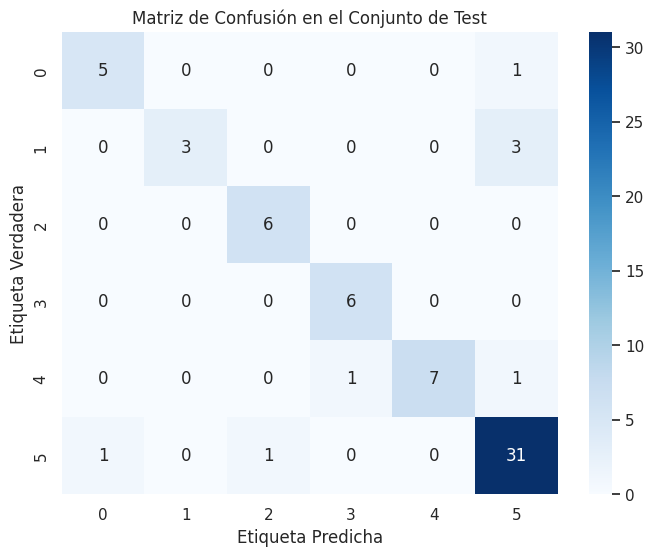


Métricas Macro en el Conjunto de Test:
F1-Macro: 0.8533
Precision-Macro: 0.9015
Recall-Macro: 0.8418


In [ ]:
# Mejores hiperparámetros para el MLP Classifier encontrados en la validación cruzada
best_mlp_params = {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001, 'solver': 'adam'}

# Inicializar el mejor modelo MLP con los hiperparámetros óptimos
best_mlp_model = MLPClassifier(max_iter=1000, random_state=42, **best_mlp_params)

# Inicializar SMOTE (se aplicará al conjunto de entrenamiento/validación completo antes del entrenamiento final)
smote_final = SMOTE(random_state=42)

# Aplicar SMOTE al conjunto de entrenamiento/validación completo
X_train_val_resampled, y_train_val_resampled = smote_final.fit_resample(X_train_val, y_train_val)

print("Entrenando el mejor modelo (MLP Classifier) en el conjunto de entrenamiento/validación completo (con SMOTE)...")
# Entrenar el modelo en el conjunto de entrenamiento/validación sobremuestreado
best_mlp_model.fit(X_train_val_resampled, y_train_val_resampled)
print("Entrenamiento completado.")

print("\nEvaluando el modelo en el conjunto de test...")
# Predecir en el conjunto de test (sin SMOTE)
y_pred_test = best_mlp_model.predict(X_test)

# Calcular métricas de desempeño en el conjunto de test
print("\nInforme de Clasificación en el Conjunto de Test:")
print(classification_report(y_test, y_pred_test))

# Matriz de Confusión en el Conjunto de Test
conf_matrix_test = confusion_matrix(y_test, y_pred_test)

print("\nMatriz de Confusión en el Conjunto de Test:")
# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', xticklabels=y.unique(), yticklabels=y.unique())
plt.title('Matriz de Confusión en el Conjunto de Test')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

# Calcular métricas macro y por clase en el conjunto de test para resumen
f1_macro_test = f1_score(y_test, y_pred_test, average='macro')
precision_macro_test = precision_score(y_test, y_pred_test, average='macro')
recall_macro_test = recall_score(y_test, y_pred_test, average='macro')

print(f"\nMétricas Macro en el Conjunto de Test:")
print(f"F1-Macro: {f1_macro_test:.4f}")
print(f"Precision-Macro: {precision_macro_test:.4f}")
print(f"Recall-Macro: {recall_macro_test:.4f}")

# Almacenar las métricas de test para referencia futura
test_metrics = {
    'f1_macro': f1_macro_test,
    'precision_macro': precision_macro_test,
    'recall_macro': recall_macro_test,
    'classification_report': classification_report(y_test, y_pred_test, output_dict=True),
    'confusion_matrix': conf_matrix_test.tolist() # Almacenar como lista para serialización si es necesario
}

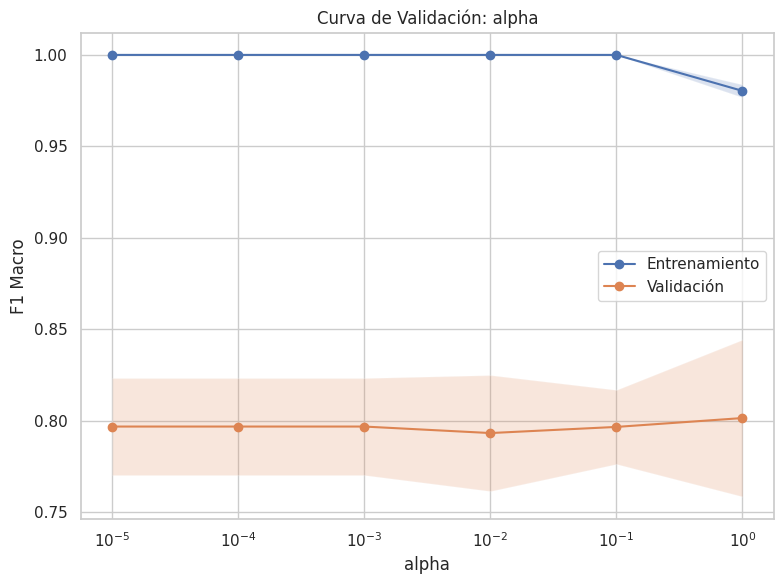

In [ ]:
# Parámetros
param_name = 'alpha'
param_range = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]

# Crear pipeline con SMOTE y MLP
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='tanh',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

# Obtener curvas de validación
train_scores, val_scores = validation_curve(
    pipeline,
    X_train_val, y_train_val,
    param_name=f'mlp__{param_name}',
    param_range=param_range,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

# Calcular promedio y desviación estándar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Visualizar curva
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_mean, label='Entrenamiento', marker='o')
plt.plot(param_range, val_mean, label='Validación', marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xscale('log')
plt.xlabel(param_name)
plt.ylabel('F1 Macro')
plt.title(f'Curva de Validación: {param_name}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Supón que X e y ya están definidos
# Define el clasificador
mlp = MLPClassifier(random_state=42, max_iter=300)

# Define SMOTE con estrategia opcional (ajústala si no quieres balancear totalmente)
smote = SMOTE(random_state=42)

# Crea el pipeline
pipeline = Pipeline([
    ('smote', smote),
    ('mlp', mlp)
])

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Usa F1 macro como métrica
f1_macro = make_scorer(f1_score, average='macro')

# Ejecuta validación cruzada con pipeline
scores = cross_val_score(pipeline, X, y, cv=cv, scoring=f1_macro)

print("F1 Macro promedio:", scores.mean())
print("Desviación estándar:", scores.std())


F1 Macro promedio: 0.8190158059434957
Desviación estándar: 0.04049082884374827


# 5. Reducción de dimensión



## 5.1 Selección de caracteristicas

9. Realice un análisis individual de cada una de las características, a partir de medidas de correlación y/o algún índice que refleje la capacidad discriminativa de las variables (según sea el caso). Identifique, de acuerdo con este análisis, sí existen y cuáles son las características candidatas a ser eliminadas.

## Correlación de Pearson
Para hacer el analisís de selección de caracteristicas emplearemos la correlación de Pearson, en el cual si se tiene un coeficiente de correlación mayor a .7 entre dos o mas predictores indica multicolinealidad (redundancia entre variables independientes)

In [ ]:
def corr_sig(predictors=None):
    p_matrix = np.zeros(shape=(predictors.shape[1],predictors.shape[1]))
    for col in predictors.columns:
        for col2 in predictors.drop(col,axis=1).columns:
            _ , p = stats.pearsonr(predictors[col],predictors[col2])
            p_matrix[predictors.columns.to_list().index(col),predictors.columns.to_list().index(col2)] = p
    return p_matrix

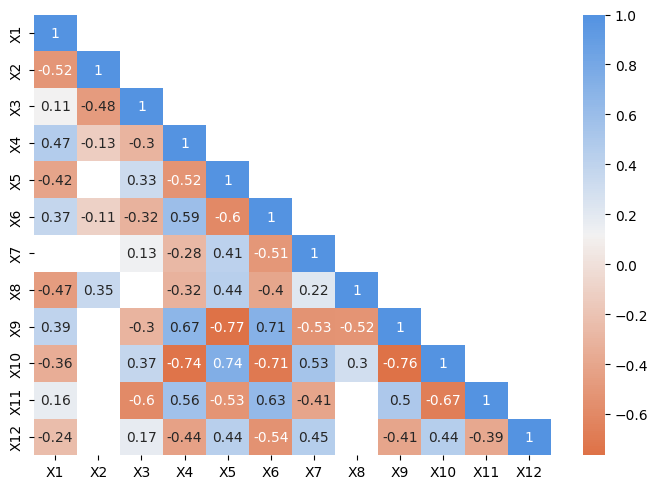

In [ ]:
p_values = corr_sig(X)

mask = np.invert(np.tril(p_values<0.05)) #0.000000000000000000000000001
corrmat = X.corr()
top_corr_predictors= corrmat.index
plt.figure(figsize=(7,5))

g=sns.heatmap(df[top_corr_predictors].corr(),annot=True,cmap=sns.diverging_palette(25, 250, s=75, l=60,n=200), mask=mask)
plt.tight_layout()

Considerando un coeficiente de correlación absoluta mayor a 0.7 según el mapa de calor, se encontraron las siguientes correlaciones fuertes:

X5 y X6 con X9

X4, X5 y X6 con X10

X9 con X10

Entonces, se perdería información si se elimina X9 o X10 ya que están fuertemente relacionadas, por lo tanto, las caracteristicas candidatas a eliminar son  X4, X5 y X6 puesto que la informacion de estas ya las aportan X9 y X10.

###10. Realice selección de características por el método de búsqueda secuencial ascendente o descendente y evalúe el subconjunto de características encontrado en los dos mejores modelos predictivos encontrados en la sección 4.


In [ ]:
# Cargar datos y preprocesar
X = df.drop('language', axis=1)
y = df['language']

# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Modelo 1: Random Forest
rfc_best = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Modelo 2: MultilayerPerceptron (MLP)
mlp_best = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation='tanh',
    solver='adam',
    alpha=0.001,
    random_state=42,
    max_iter=500
)

#Búsqueda Secuencial Ascendente para Random Forest
sfs_rfc = SFS(rfc_best,
              k_features='best',
              forward=True,
              floating=False,
              scoring='f1_weighted',
              cv=stratified_cv,
              n_jobs=-1)

sfs_rfc.fit(X_train_scaled, y_train)

print('Mejor subconjunto de características para Random Forest:', sfs_rfc.k_feature_names_)
print('Mejor puntuación de accuracy (CV):', sfs_rfc.k_score_)


#Búsqueda Secuencial Ascendente para MLP
sfs_mlp = SFS(mlp_best,
              k_features='best',
              forward=True,
              floating=False,
              scoring='f1_weighted',
              cv=stratified_cv,
              n_jobs=-1)

sfs_mlp.fit(X_train_scaled, y_train)

print('\nMejor subconjunto de características para MLP:', sfs_mlp.k_feature_names_)
print('Mejor puntuación de f1_weighted (CV):', sfs_mlp.k_score_)


#Evaluación de los subconjuntos encontrados
#Extraer los subconjuntos seleccionados
X_train_sfs_rfc = sfs_rfc.transform(X_train_scaled)
X_test_sfs_rfc = sfs_rfc.transform(X_test_scaled)

X_train_sfs_svc = sfs_mlp.transform(X_train_scaled)
X_test_sfs_svc = sfs_mlp.transform(X_test_scaled)

#Re-entrenar y evaluar Random Forest
rfc_best.fit(X_train_sfs_rfc, y_train)
y_pred_sfs_rfc = rfc_best.predict(X_test_sfs_rfc)
print(f"\nAccuracy de Random Forest con SFS: {accuracy_score(y_test, y_pred_sfs_rfc):.4f}")

#Re-entrenar y evaluar SVC
mlp_best.fit(X_train_sfs_svc, y_train)
y_pred_sfs_svc = mlp_best.predict(X_test_sfs_svc)
print(f"Accuracy de MLP con SFS: {accuracy_score(y_test, y_pred_sfs_svc):.4f}")

Mejor subconjunto de características para Random Forest: ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12')
Mejor puntuación de accuracy (CV): 0.9143067801763454

Mejor subconjunto de características para MLP: ('0', '2', '3', '4', '6', '7', '8', '9', '10', '11', '12')
Mejor puntuación de f1_weighted (CV): 0.9201311249137337

Accuracy de Random Forest con SFS: 0.8788
Accuracy de MLP con SFS: 0.8485


In [ ]:
resultados = pd.DataFrame([
    {
        'Modelo': 'Random Forest',
        'Características Iniciales': X_train.shape[1],
        'Características Seleccionadas': len(sfs_rfc.k_feature_idx_),
        'Reducción (%)': 100 * (X_train.shape[1] - len(sfs_rfc.k_feature_idx_)) / X_train.shape[1],
        'Accuracy': accuracy_score(y_test, y_pred_sfs_rfc),
        'F1-weighted': f1_score(y_test, y_pred_sfs_rfc, average='weighted'),
        'Recall-weighted': recall_score(y_test, y_pred_sfs_rfc, average='weighted'),
        'Precision-weighted': precision_score(y_test, y_pred_sfs_rfc, average='weighted'),
    },
    {
        'Modelo': 'MLP',
        'Características Iniciales': X_train.shape[1],
        'Características Seleccionadas': len(sfs_mlp.k_feature_idx_),
        'Reducción (%)': 100 * (X_train.shape[1] - len(sfs_mlp.k_feature_idx_)) / X_train.shape[1],
        'Accuracy': accuracy_score(y_test, y_pred_sfs_svc),
        'F1-weighted': f1_score(y_test, y_pred_sfs_svc, average='weighted'),
        'Recall-weighted': recall_score(y_test, y_pred_sfs_svc, average='weighted'),
        'Precision-weighted': precision_score(y_test, y_pred_sfs_svc, average='weighted'),
    }
])

# Mostrar la tabla
pd.set_option('display.precision', 4)
print(resultados)


          Modelo  Características Iniciales  Características Seleccionadas  \
0  Random Forest                         12                             11   
1            MLP                         12                             11   

   Reducción (%)  Accuracy  F1-weighted  Recall-weighted  Precision-weighted  
0         8.3333    0.7879       0.7659           0.7879              0.8141  
1         8.3333    0.7576       0.7376           0.7576              0.7577  


Dado que el conjunto de datos presenta un fuerte desbalance de clases (por ejemplo, la clase US tiene más de cinco veces más muestras que FR, IT, GE o ES), utilizamos como función criterio el f1_weighted durante la selección de características.
Esta métrica combina precisión y recall, y ajusta el impacto de cada clase de acuerdo con su frecuencia. De esta forma, evitamos que la selección de características favorezca únicamente el desempeño sobre la clase mayoritaria, y obtenemos un subconjunto de características que mantiene un rendimiento más equilibrado entre clases.

## 5.2 Extracción de caracteristicas

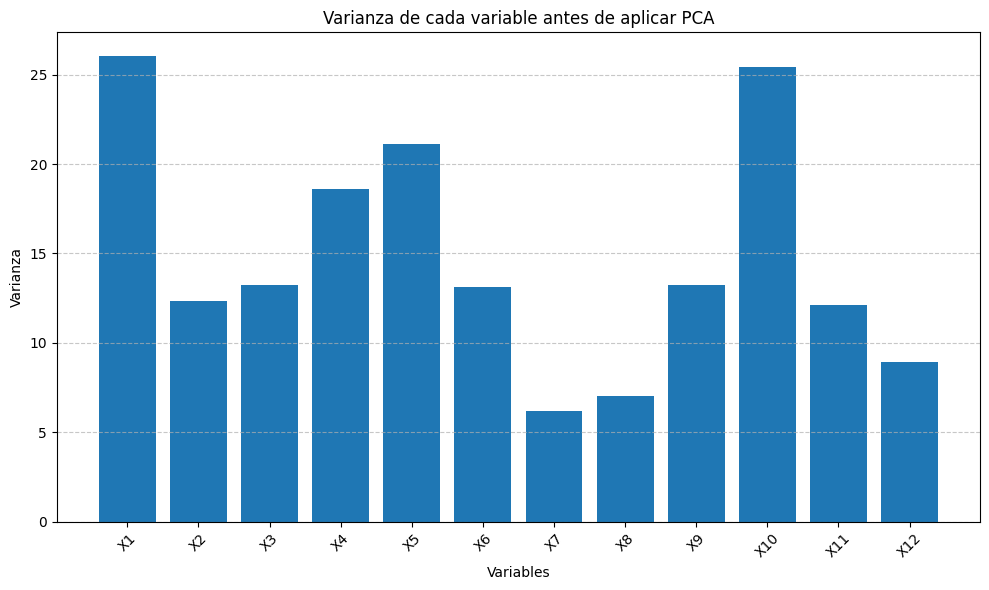

In [ ]:
variances = X.var()

plt.figure(figsize=(10, 6))
plt.bar(range(len(variances)), variances.values, tick_label=variances.index)
plt.ylabel('Varianza')
plt.xlabel('Variables')
plt.title('Varianza de cada variable antes de aplicar PCA')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
n_components = 5
pca = PCA(n_components=n_components, random_state=42)

scaler = StandardScaler()
norm_predictors = scaler.fit_transform(X)

X_pca = pca.fit_transform(norm_predictors)
X_pca = pd.DataFrame(X_pca, columns=["PC%d" % (x + 1) for x in range(n_components)])

print("Suma de la proporcion de la varianza explicada por {} componentes PCA: ".format(n_components),round(sum(pca.explained_variance_ratio_),2))

print("\nproporcion de la varianza explicada por cada componente PCA")
print(pca.explained_variance_ratio_)


Suma de la proporcion de la varianza explicada por 5 componentes PCA:  0.84

proporcion de la varianza explicada por cada componente PCA
[0.45760942 0.16990422 0.08687493 0.0741524  0.05377289]


In [ ]:
X_pca.head()

,PC1,PC2,PC3,PC4,PC5
0,-1.2267,-1.4061,-1.1865,-0.2768,-0.2840
1,-1.8160,-0.8731,-0.5867,0.0932,-0.4640
2,-1.1201,-0.9822,-2.0197,-0.0214,-0.3778
3,-0.9790,-0.5316,-1.6128,0.4331,-0.1750
4,-1.0998,-0.7168,-1.7083,0.0438,-0.3560


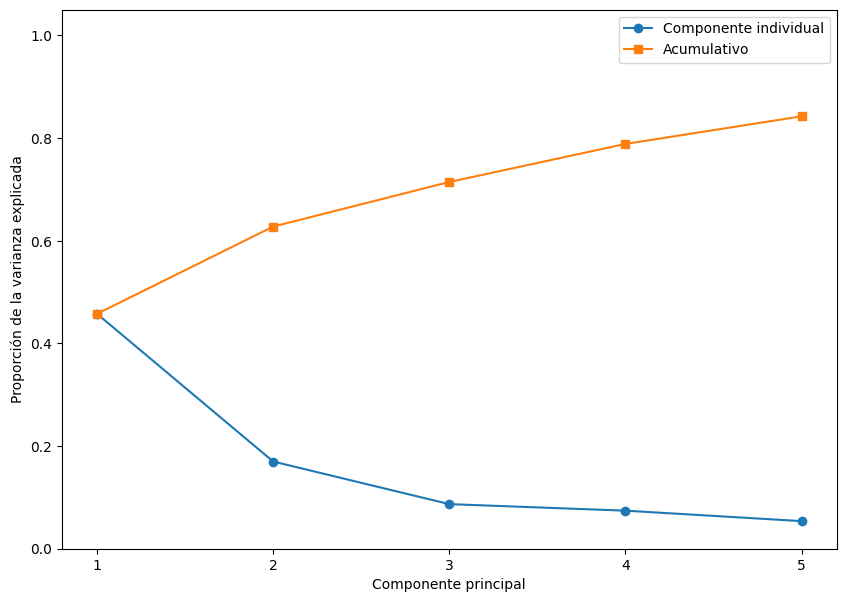

In [ ]:
plt.figure(figsize=(10,7))
plt.plot([1,2,3,4,5], pca.explained_variance_ratio_, '-o', label='Componente individual')
plt.plot([1,2,3,4,5], np.cumsum(pca.explained_variance_ratio_), '-s', label='Acumulativo')
#1,2,3,4 to avoid PCA1 is at 0 in xscale

plt.ylabel('Proporción de la varianza explicada')
plt.xlabel('Componente principal')
plt.xlim(0.8,5.2)
plt.ylim(0,1.05)
plt.xticks([1,2,3,4,5])
plt.legend();

Entrenando MLPClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Entrenando RandomForestClassifier...

===== MLP Classifier =====
              precision  recall  f1-score  support
ES               0.5714  0.6667    0.6154   6.0000
FR               1.0000  0.5000    0.6667   6.0000
GE               0.6250  0.8333    0.7143   6.0000
IT               0.1667  0.1667    0.1667   6.0000
UK               0.4545  0.5556    0.5000   9.0000
US               0.7419  0.6970    0.7188  33.0000
accuracy         0.6212  0.6212    0.6212   0.6212
macro avg        0.5933  0.5699    0.5636  66.0000
weighted avg     0.6478  0.6212    0.6242  66.0000


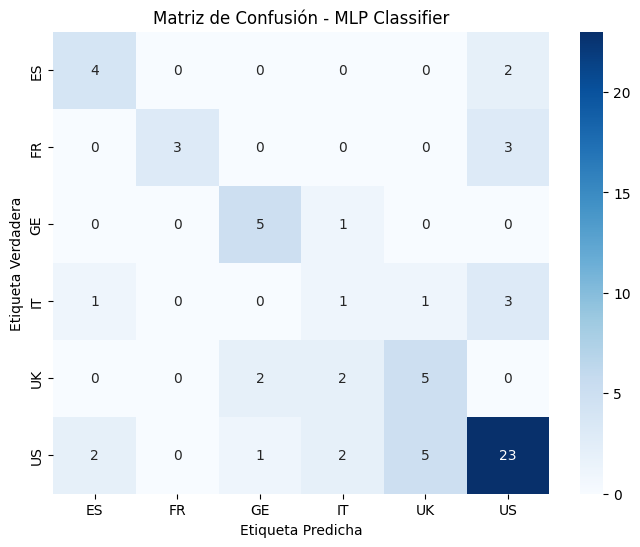


Random Forest Classifier 
              precision  recall  f1-score  support
ES               0.6667  0.6667    0.6667   6.0000
FR               0.7500  0.5000    0.6000   6.0000
GE               0.5455  1.0000    0.7059   6.0000
IT               0.5000  0.3333    0.4000   6.0000
UK               0.4167  0.5556    0.4762   9.0000
US               0.8276  0.7273    0.7742  33.0000
accuracy         0.6667  0.6667    0.6667   0.6667
macro avg        0.6177  0.6305    0.6038  66.0000
weighted avg     0.6944  0.6667    0.6677  66.0000


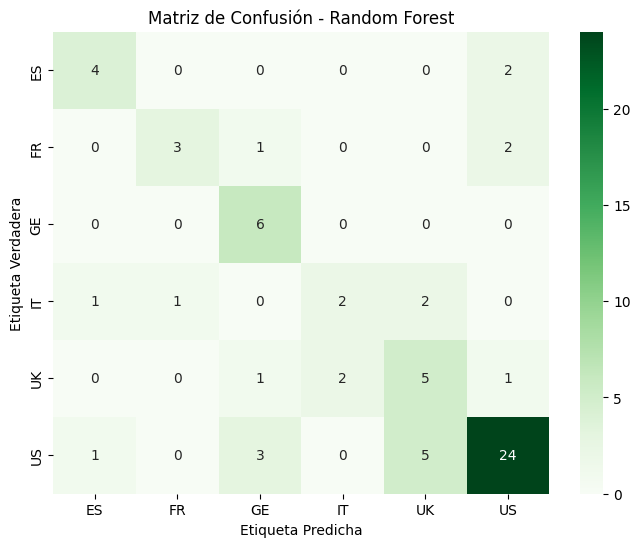


Comparación de Métricas (Macro)
                F1 Macro  Precisión Macro  Recall Macro
Modelo                                                 
MLP Classifier    0.5636           0.5933        0.5699
Random Forest     0.6038           0.6177        0.6305


In [ ]:
# Codificar la variable objetivo
le = LabelEncoder()
y_encoded = le.fit_transform(df['language'])

#Dividir en conjunto de entrenamiento/validación y prueba
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_pca, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

#Aplicar SMOTE para balancear las clases
smote = SMOTE(random_state=42)
X_train_val_resampled, y_train_val_resampled = smote.fit_resample(X_train_val, y_train_val)

#Inicializar modelos con mejores hiperparámetros
best_mlp = MLPClassifier(
    max_iter=1000,
    random_state=42,
    activation='tanh',
    alpha=0.001,
    hidden_layer_sizes=(50, 50),
    learning_rate_init=0.001,
    solver='adam'
)

best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

#Entrenamiento
print("Entrenando MLPClassifier...")
best_mlp.fit(X_train_val_resampled, y_train_val_resampled)

print("Entrenando RandomForestClassifier...")
best_rf.fit(X_train_val_resampled, y_train_val_resampled)


#EVALUACIÓN MLP

y_pred_mlp = best_mlp.predict(X_test)
report_mlp = classification_report(y_test, y_pred_mlp, target_names=le.classes_, output_dict=True)
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)

print("\n===== MLP Classifier =====")
print(pd.DataFrame(report_mlp).transpose())

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión - MLP Classifier')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

f1_mlp = f1_score(y_test, y_pred_mlp, average='macro')
precision_mlp = precision_score(y_test, y_pred_mlp, average='macro')
recall_mlp = recall_score(y_test, y_pred_mlp, average='macro')


#EVALUACIÓN RF

y_pred_rf = best_rf.predict(X_test)
report_rf = classification_report(y_test, y_pred_rf, target_names=le.classes_, output_dict=True)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print("\nRandom Forest Classifier ")
print(pd.DataFrame(report_rf).transpose())

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

f1_rf = f1_score(y_test, y_pred_rf, average='macro')
precision_rf = precision_score(y_test, y_pred_rf, average='macro')
recall_rf = recall_score(y_test, y_pred_rf, average='macro')


#COMPARACIÓN FINAL

summary_df = pd.DataFrame([
    {
        'Modelo': 'MLP Classifier',
        'F1 Macro': f1_mlp,
        'Precisión Macro': precision_mlp,
        'Recall Macro': recall_mlp
    },
    {
        'Modelo': 'Random Forest',
        'F1 Macro': f1_rf,
        'Precisión Macro': precision_rf,
        'Recall Macro': recall_rf
    }
])

print("\nComparación de Métricas (Macro)")
print(summary_df.set_index('Modelo'))
